In [1]:
%pip install gurobipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from sklearn.preprocessing import

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F

import gurobipy as gp
from gurobipy import GRB

# Optional: torch_geometric for graph layers
try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data as GeoData
except Exception:
    GATConv = None
    GeoData = None


# Data Prep


In [3]:
data_23_24 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fantasyGo_FPL.csv')
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')

# data_24_25 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fantasyGo_FPL_24_25.csv')
# fg_managers_24_25 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fantasyGo%2024-25.csv')

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'score', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'score_bps_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'score_bps_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]


cols = [ 'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'round', 'fpl_name', 'xP', 'team', 'opponent_team', 'position',


        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_difficulty',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',

        ]


## 23/24 - Data Prep


In [5]:
play_data = data_23_24.copy()


play_data['gw'] = play_data['round']
play_data['team'] = play_data['player_team']
play_data['opponent_team'] = play_data.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
play_data[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]

team_df = play_data.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)

team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df = play_data.merge(team_df, on=['opponent_team', 'team','gw'], how='left')

# ODI = Probability of Draw + Probability of Away Win (assuming player's team is Home odds)
# A high ODI means a tough fixture (Player's team is less likely to win).
# ODI = Probability of Draw + Probability of Home Win (assuming player's team is Away odds)
# A high ODI means a tough fixture (Player's team is more likely to win).
final_df['opponent_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['h_team']
    else (row['whd'] + row['whh']),
    axis=1
)

final_df['team_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['a_team']
    else (row['whd'] + row['whh']),
    axis=1
)


CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(final_df[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(final_df[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=final_df.index
)


cols = [*cols, *encoded_cols]
# Combine with numerical data
final_df = pd.concat([final_df, encoded_df], axis=1) #.drop(columns=CATEGORICAL_COLS)
final_df

,Unnamed: 0,fpl_id,round,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,...,opponent_team_Liverpool,opponent_team_Luton,opponent_team_Manchester City,opponent_team_Manchester United,opponent_team_Newcastle United,opponent_team_Nottingham Forest,opponent_team_Sheffield United,opponent_team_Tottenham Hotspur,opponent_team_West Ham United,opponent_team_Wolverhampton Wanderers
0,0,145,1,0.0,0.0,9.0,0.0,0.0,145.0,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,151,1,0.0,0.0,2.0,0.0,0.3,151.0,0.00,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,401,1,1.0,3.0,40.0,1.0,37.4,401.0,0.78,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,131,1,1.0,3.0,34.0,0.0,79.3,131.0,0.86,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,143,1,1.0,1.0,26.0,0.0,61.9,143.0,0.62,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4921,4921,421,38,0.0,0.0,12.0,0.0,2.3,421.0,0.06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4922,4922,544,38,0.0,0.0,14.0,0.0,0.2,544.0,0.00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4923,4923,545,38,0.0,0.0,11.0,0.0,12.4,545.0,0.08,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4924,4924,70,38,0.0,0.0,3.0,0.0,0.2,70.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
final_df['team'].unique(), len(final_df['team'].unique())

(array(['Chelsea', 'Brighton and Hove Albion', 'Manchester United',
        'West Ham United', 'Crystal Palace', 'Manchester City', 'Arsenal',
        'Newcastle United', 'Sheffield United', 'Luton', 'Fulham',
        'Aston Villa', 'Everton', 'Brentford', 'Liverpool',
        'Tottenham Hotspur', 'Bournemouth', 'Burnley', 'Nottingham Forest',
        'Wolverhampton Wanderers', 'Mainz 05'], dtype=object),
 21)

In [ ]:

final_df[final_df['team'] == 'Mainz 05'][['fpl_name','round',  'FPL_Name', 'date', 'a_team', 'h_team']]

,fpl_name,round,FPL_Name,date,a_team,h_team
3370,David Datro Fofana,26,David Datro Fofana,2024-02-24,Burnley,Crystal Palace
3490,David Datro Fofana,27,David Datro Fofana,2024-03-03,Bournemouth,Burnley
3665,David Datro Fofana,29,David Datro Fofana,2024-03-16,Brentford,Burnley
3934,David Datro Fofana,31,David Datro Fofana,2024-04-02,Wolverhampton Wanderers,Burnley
4225,David Datro Fofana,33,David Datro Fofana,2024-04-13,Brighton and Hove Albion,Burnley
4287,David Datro Fofana,34,David Datro Fofana,2024-04-20,Burnley,Sheffield United
4631,David Datro Fofana,36,David Datro Fofana,2024-05-04,Newcastle United,Burnley


In [39]:
# Cole Palmer is still in mancity not chelsea
# Fofana moved to chealse mid season
final_df.loc[final_df['FPL_Name'] == 'Cole Palmer', 'team'] = 'Chelsea'
final_df.loc[final_df['team'] == 'Mainz 05', 'team'] = 'Chelsea'
final_df['team'].unique(), len(final_df['team'].unique())

(array(['Chelsea', 'Brighton and Hove Albion', 'Manchester United',
        'West Ham United', 'Crystal Palace', 'Manchester City', 'Arsenal',
        'Newcastle United', 'Sheffield United', 'Luton', 'Fulham',
        'Aston Villa', 'Everton', 'Brentford', 'Liverpool',
        'Tottenham Hotspur', 'Bournemouth', 'Burnley', 'Nottingham Forest',
        'Wolverhampton Wanderers'], dtype=object),
 20)

## 24/25 - Data Prep


In [40]:
play_data_45 = data_24_25.copy()


play_data_45['gw'] = play_data_45['round']
play_data_45['team'] = play_data_45['player_team']
play_data_45['opponent_team'] = play_data_45.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
play_data_45[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]

team_df = play_data_45.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df_45 = play_data_45.merge(team_df, on=['opponent_team', 'team','gw'], how='left')

# ODI = Probability of Draw + Probability of Away Win (assuming player's team is Home odds)
# A high ODI means a tough fixture (Player's team is less likely to win).
# ODI = Probability of Draw + Probability of Home Win (assuming player's team is Away odds)
# A high ODI means a tough fixture (Player's team is more likely to win).
final_df_45['opponent_difficulty'] = final_df_45.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['h_team']
    else (row['whd'] + row['whh']),
    axis=1
)

final_df_45['team_difficulty'] = final_df_45.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['a_team']
    else (row['whd'] + row['whh']),
    axis=1
)

 # Load the saved encoder


encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)

print(encoded_cols)

# Transform only (DO NOT FIT)
encoded_array = encoder.transform(final_df_45[CATEGORICAL_COLS])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_cols,
    index=final_df_45.index
)



# Combine
final_df_45 = pd.concat([final_df_45, encoded_df], axis=1) #.drop(columns=CATEGORICAL_COLS)

['position_DEF' 'position_FWD' 'position_GK' 'position_MID' 'team_Arsenal'
 'team_Aston Villa' 'team_Bournemouth' 'team_Brentford'
 'team_Brighton and Hove Albion' 'team_Burnley' 'team_Chelsea'
 'team_Crystal Palace' 'team_Everton' 'team_Fulham' 'team_Liverpool'
 'team_Luton' 'team_Mainz 05' 'team_Manchester City'
 'team_Manchester United' 'team_Newcastle United' 'team_Nottingham Forest'
 'team_Sheffield United' 'team_Tottenham Hotspur' 'team_West Ham United'
 'team_Wolverhampton Wanderers' 'opponent_team_Arsenal'
 'opponent_team_Aston Villa' 'opponent_team_Bournemouth'
 'opponent_team_Brentford' 'opponent_team_Brighton and Hove Albion'
 'opponent_team_Burnley' 'opponent_team_Chelsea'
 'opponent_team_Crystal Palace' 'opponent_team_Everton'
 'opponent_team_Fulham' 'opponent_team_Liverpool' 'opponent_team_Luton'
 'opponent_team_Manchester City' 'opponent_team_Manchester United'
 'opponent_team_Newcastle United' 'opponent_team_Nottingham Forest'
 'opponent_team_Sheffield United' 'opponent

### Predictors


In [6]:
# --- Step 1: Data Preparation Function ---

def prepare_fpl_data(data, cols):
    """
    Prepares features (X), conditional parameters (M), targets (Y),
    and gameweeks (GW) for the AffinePNN model.
    """
    cols_ = list(cols)
    if 'team_difficulty' not in cols_:
        cols_.append('team_difficulty')

    data_ = data[cols_].copy()

    # Target and metadata columns
    target_col = ['xP', 'fpl_name']
    gameweek_col = 'round'
    POSITION_COL = 'position'
    M_COLS = ['opponent_difficulty' , 'team_difficulty' , 'was_home'] #, 'whh', 'whd', 'wha'

    # Handle Categorical Features
    CATEGORICAL_COLS = [POSITION_COL, 'team', 'opponent_team']

    data_ = data_.drop(columns=CATEGORICAL_COLS)
    # df = pd.get_dummies(data_, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, dummy_na=False)
    # print('----->', data_.shape)
    # print('<-----', df.shape,CATEGORICAL_COLS )
    # 2. Target Variable (Y)
    Y = data_[target_col].fillna(0)

    # 3. Input Features (X)
    EXCLUDE_COLS = [*target_col, gameweek_col, *M_COLS]

    # Find position-related columns for explicit inclusion if needed
    new_position_cols = [col for col in data_.columns if col.startswith(f'{POSITION_COL}_')]

    # Filter feature columns
    X_cols = [c for c in data_.columns if c not in EXCLUDE_COLS and c != POSITION_COL]

    # Final check of column existence
    X_cols = [col for col in X_cols if col in data_.columns]

    # Convert to numpy
    X = data_[X_cols].fillna(0).values.astype(np.float32)
    M = data_[M_COLS].fillna(0).values.astype(np.float32)
    GW = data_[gameweek_col].values

    print(f"Data prepared. X shape: {X.shape}, M shape: {M.shape}, Y shape: {Y.shape}")
    return X, M, Y, GW, X_cols


def transform_data(final_df, cols, gw):
    # Prepare data
    X_full, M_full, Y_full, GW_full, X_cols = prepare_fpl_data(final_df, cols)
    # print(X_full.shape)
    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    X_train, M_train, Y_train_raw = X_full[train_mask], M_full[train_mask], Y_full[train_mask]
    X_test, M_test, Y_test_raw = X_full[test_mask], M_full[test_mask], Y_full[test_mask]

    Y_train = Y_train_raw['xP'].values
    Y_train_names = Y_train_raw['fpl_name'].values

    Y_test = Y_test_raw['xP'].values
    Y_test_names = Y_test_raw['fpl_name'].values

    # Scaling
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)

    if X_test.size > 0:
        X_test_scaled = scaler_x.transform(X_test)
    else:
        X_test_scaled = scaler_x

    scaler_m = StandardScaler()
    M_train_scaled = scaler_m.fit_transform(M_train)

    if M_test.size > 0:
        M_test_scaled = scaler_m.transform(M_test)
    else:
        M_test_scaled = scaler_m

    # print('----', Y_train)

    return (X_train_scaled, M_train_scaled, train_mask, Y_train, Y_train_names), (X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names), GW_full, X_cols#, scaler_x, scaler_m


# --- Step 2: Custom Affine Conditioning Layer ---

class AffineConditioning(Layer):
    """
    Custom Keras Layer implementing the core Affine Parametric Neural Network (AffinePNN) logic.
    z = (phi * m + s0) * x + (psi * m + b0)
    """
    def __init__(self, units, activation=None, **kwargs):
        super(AffineConditioning, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape: [feature_input_shape, parameter_input_shape]
        feature_dim = input_shape[0][-1]
        param_dim = input_shape[1][-1]

        # Weights to transform the parameter 'm' into scale and bias adjustments
        # Shape is (param_dim, feature_dim) to map conditions to feature space
        self.phi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='phi')
        self.psi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='psi')

        # Base scaling and bias
        self.s0 = self.add_weight(shape=(feature_dim,), initializer='ones', trainable=True, name='s0')
        self.b0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='b0')

        self.built = True

    def call(self, inputs):
        x_in, m = inputs # x_in: (batch, feat), m: (batch, cond)

        # Calculate scale and bias based on conditional input m
        # (batch, cond) @ (cond, feat) -> (batch, feat)
        s_m = tf.matmul(m, self.phi)
        b_m = tf.matmul(m, self.psi)

        s = s_m + self.s0
        b = b_m + self.b0

        # Apply affine transformation
        x_out = s * x_in + b

        if self.activation is not None:
            return self.activation(x_out)
        return x_out

    def get_config(self):
        config = super(AffineConditioning, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return config

# --- Step 3: Model Architecture ---

def build_affine_pnn(input_dim_x, input_dim_m, output_dim_y, hidden_units=128):
    """
    Builds the Affine Parametric Neural Network (AffinePNN) Model.
    """
    L2_REG = 0.001

    X_input = Input(shape=(input_dim_x,), name='X_input')
    M_input = Input(shape=(input_dim_m,), name='M_input')

    # Initial Dense Layer
    x = Dense(hidden_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_1')(X_input)

    # Affine Conditioning Block 1
    x = AffineConditioning(units=hidden_units, activation='relu', name='Affine_Cond_1')([x, M_input])

    # Standard Dense Layer
    x = Dense(hidden_units // 2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_2')(x)

    # Affine Conditioning Block 2
    x = AffineConditioning(units=hidden_units // 2, activation='relu', name='Affine_Cond_2')([x, M_input])

    # Final Prediction Layer
    output = Dense(output_dim_y, activation='linear', name='Output')(x)

    model = Model(inputs=[X_input, M_input], outputs=output, name='AffinePNN_FPL')
    return model

def plot_training_history(history):
    """
    Plots the training and validation loss/metrics including MSE.
    """
    metrics = ['loss', 'mae', 'mse']
    plt.figure(figsize=(18, 5))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i + 1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Validation')
        plt.title(f'Model {metric.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.upper())
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def evaluator(model, X_test_scaled, M_test_scaled, Y_test):
    # 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
    print("\nEvaluating test set performance...")
    test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

    # Generate predictions to calculate R2 score manually
    Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()
    r2 = r2_score(Y_test, Y_pred)

    evaluation_metrics = {
        'test_loss': test_results['loss'],
        'test_mae': test_results['mae'],
        'test_mse': test_results['mse'],
        'test_R2': r2
    }


    return evaluation_metrics



### Optimizers


#### IRL for HEPs


In [7]:
def greedy_expert_strategy(players, hist_xp=None, K=15, max_team_ratio=3, corr_threshold=0.8):
    """
    Greedy selection that picks top xP_pred players while respecting
    team (club) caps and avoiding players highly correlated in historical xP.
    Returns a binary selection vector for the N players.
    (Paper: Heuristic-Guided Inverse RL -> Expert Trajectory Generation)
    """
    N = len(players)
    # Prioritize higher predicted points
    order = players.sort_values('xP_pred', ascending=False).index.tolist()
    selected = []
    team_counts = {}

    # Compute correlation matrix if hist_xp provided
    corr = None
    if hist_xp is not None:
        try:
            # Use Pearson correlation (linear relationship)
            corr = np.corrcoef(hist_xp, rowvar=False)
            corr = np.nan_to_num(corr)
        except Exception:
            corr = None

    for idx in order:
        if len(selected) >= K:
            break

        # Check FPL Club Constraint (Heuristic Rule 1)
        team = players.loc[idx, 'team']
        if team_counts.get(team, 0) >= max_team_ratio:
            continue

        # Check Correlation Constraint (Heuristic Rule 2: Correlation Control)
        if corr is not None and len(selected) > 0:
            # Calculate average positive correlation with already selected players
            selected_indices = [players.index.get_loc(s) for s in selected]
            player_idx = players.index.get_loc(idx)

            # Avg positive correlation with selected players
            correlations = [corr[player_idx, s_idx] for s_idx in selected_indices if corr[player_idx, s_idx] > 0]
            if correlations and np.mean(correlations) >= corr_threshold:
                continue

        selected.append(players.loc[idx, 'player_id'])
        team_counts[team] = team_counts.get(team, 0) + 1

    # Return selection vector based on original index (player_id)
    sel_vec = np.zeros(N, dtype=int)
    for p_id in selected:
        sel_vec[p_id] = 1
    return sel_vec

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r

# -------------------------------------------------------------------------
# 3. REWARD LEARNING (MAXENT IRL)
# -------------------------------------------------------------------------

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        # Maximizing E_expert[R] equivalent to Minimizing -E_expert[R]

        # Safe division
        expert_sum = expert_mask.sum()
        if expert_sum == 0:
            expert_term = 0
        else:
            expert_term = (r * expert_mask).sum() / expert_sum

        loss = - expert_term
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()

        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        ptp = np.ptp(learned_r)
        if ptp == 0: ptp = 1e-8
        learned_r = (learned_r - learned_r.min()) / ptp
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Simplified MaxEnt IRL training -------------------

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        loss = - (r * expert_mask).sum() / expert_mask.sum()  # Maximize E_expert[R]
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()
        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        # learned_r.ptp()
        learned_r = (learned_r - learned_r.min()) / (np.ptp(learned_r) + 1e-8)
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Heterogeneous Graph Attention -------------------

class HGATPolicy(nn.Module):
    """
    A small HGAT that uses GATConv (if available) to produce player embeddings.
    (Paper: Heterogeneous Graph Policy Learning)
    """
    def __init__(self, in_dim, out_dim=32, heads=4):
        super().__init__()
        if GATConv is None:
            # fallback: MLP
            self.fallback = True
            self.mlp = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, out_dim))
        else:
            self.fallback = False
            self.conv1 = GATConv(in_dim, 32, heads=heads, concat=True)
            self.conv2 = GATConv(32*heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index=None):
        if self.fallback:
            return self.mlp(x)
        else:
            # Here, the HGAT would combine information from correlation graphs and team graphs.
            h = F.elu(self.conv1(x, edge_index))
            h = self.conv2(h, edge_index)
            return h

def ilp_select_squad(players, combined_score, budget=100.0, max_budget_per_pos=None):
    """
    Use Gurobi to select the optimal 11-man starting team and the captain.

    (Paper: Final Portfolio Optimization via Policy Output)
    """
    N = len(players)
    m = gp.Model("FPL_11_Man_Squad")
    m.Params.OutputFlag = 0 # Suppress Gurobi output

    # Decision Variables
    # x represents the 11 selected players (now the only selection variable)
    x = m.addVars(N, vtype=GRB.BINARY, name="x_selected")
    # z represents the Captain selection (1 player)
    z = m.addVars(N, vtype=GRB.BINARY, name="z_captain")

    # ------------------ OBJECTIVE FUNCTION ------------------
    # Maximize total score: Sum of (Selected Player Score) + (Captain Score Bonus)
    total_score = gp.quicksum(combined_score[i] * x[i] for i in range(N))
    captain_bonus = gp.quicksum(combined_score[i] * z[i] for i in range(N))
    m.setObjective(total_score + captain_bonus, GRB.MAXIMIZE)

    # ------------------ CONSTRAINTS ------------------

    # C1: Total size must be exactly 11 players
    m.addConstr(gp.quicksum(x[i] for i in range(N)) == 11, "Squad_Size_11")

    # C2: Budget constraint for the 11-man squad
    # Note: The budget is now used entirely for the 11 players.
    m.addConstr(gp.quicksum(players.loc[i,'price'] * x[i] for i in range(N)) <= budget, "Budget_Constraint")

    # C3: Club max 3 players in the 11-man squad
    clubs = players['team'].unique()
    for team in clubs:
        m.addConstr(gp.quicksum(x[i] for i in range(N) if players.loc[i,'team']==team) <= 3, f"Club_Limit_{team}")

    # C4: Captain selection (exactly 1 player)
    m.addConstr(gp.quicksum(z[i] for i in range(N)) == 1, "Captain_Select_1")

    # C5: Link between Captain and Selection: The captain must be one of the 11 selected players
    m.addConstrs((z[i] <= x[i] for i in range(N)), name="Captain_is_Selected")

    # C6: Formation constraint (Position limits for the 11 players)
    # Min/Max rules for the starting 11: 1 GK, 3-5 DEF, 2-5 MID, 1-3 FWD
    formation_limits = {
        "GK": (1, 1), # Exactly 1 GK must start
        "DEF": (3, 5),
        "MID": (2, 5),
        "FWD": (1, 3)
    }
    for pos, (min_req, max_req) in formation_limits.items():
        pos_selected = gp.quicksum(x[i] for i in range(N) if players.loc[i,'position']==pos)
        m.addConstr(pos_selected >= min_req, f"Selection_Min_{pos}")
        m.addConstr(pos_selected <= max_req, f"Selection_Max_{pos}")


    m.optimize()

    # Extract Results
    selected_ids = []
    captain_id = -1

    if m.status == GRB.OPTIMAL:
        for i in range(N):
            if x[i].X > 0.5:
                selected_ids.append(players.loc[i, 'player_id'])
            if z[i].X > 0.5:
                captain_id = players.loc[i, 'player_id']

    # Since we only selected 11, the "starter" list is the same as the "squad" list
    return selected_ids, selected_ids, captain_id

# ----------------------------- Putting it together -----------------------

def run_pipeline(players):
    """Main function to run the IRL-HGAT-ILP FPL optimization pipeline."""
    # Step 1: Data Generation
    # players, hist = make_dummy_players(n_players=90, seed=42)

    # players
    hist = None

    # Step 2: Generate Expert Strategy (Heuristic-Guided Trajectory)
    # Note: K=11 for the expert selection now, to match the final goal.
    expert_sel = greedy_expert_strategy(
        players,
        hist_xp=hist,
        K=11, # Changed to 11
        max_team_ratio=3,
        corr_threshold=0.85 # Tighter correlation constraint for the expert
    )
    print(f"Expert selected count (11-man heuristic): {expert_sel.sum()}")

    # Step 3: Train Simplified MaxEnt IRL (Multi-Objective Reward Learning)
    net, players = maxent_irl_train(players.copy(), expert_sel, epochs=200, lr=5e-3)

    # Step 4: HGAT Policy (Feature Embedding, simulates cross-player understanding)
    N = len(players)
    # Build graph edges based on club affiliation (Industry/Sector Graph in the paper)

    edge_idx = []
    for i in range(N):
        for j in range(i + 1, N):
            # print(i, j)
            if players.loc[i,'team'] == players.loc[j,'team']:
                # Bidirectional edge
                edge_idx.append([i, j])
                edge_idx.append([j, i])
    edge_index = torch.tensor(edge_idx, dtype=torch.long).t().contiguous() if edge_idx else None

    # Node features: price, xP_pred, learned_r, one-hot pos
    pos_map = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
    pos_onehot = np.zeros((N, 4))
    for i, p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([
        players[['price', 'xP_pred', 'learned_r']].values,
        pos_onehot
    ], axis=1)
    X_t = torch.tensor(X, dtype=torch.float32)

    policy = HGATPolicy(in_dim=X.shape[1])
    with torch.no_grad():
        emb = policy(X_t, edge_index)
    print(f"HGAT Policy Embeddings Shape: {emb.shape}")

    # Step 5: Final ILP Optimization using Combined Score
    # We combine the "raw return" (xP_pred) with the "learned reward" (risk/diversity value)
    combined_score = (
        0.6 * players['xP_pred'].values +
        0.4 * players['learned_r'].values
    )

    # Note: The 'squad_sel_ids' and 'starter_sel_ids' are now identical (the 11 players)
    selected_ids, _, captain_id = ilp_select_squad(
        players,
        combined_score,
        budget=100.0 # Adjusted budget for a likely 11-man team
    )

    print("\n--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---")
    if selected_ids and len(selected_ids) == 11:
        squad_df = players[players['player_id'].isin(selected_ids)].copy()
        squad_df['Is_Captain'] = squad_df['player_id'] == captain_id

        # Calculate total score from the optimal selection
        total_xp_maximized = squad_df['xP_pred'].sum()
        captain_xp = squad_df[squad_df['Is_Captain']]['xP_pred'].iloc[0]
        total_xp_maximized += captain_xp # Add bonus points

        print(squad_df[['name','team','position','price','xP_pred', 'Is_Captain']].sort_values(by=['position', 'price'], ascending=[False, False]))
        print("\n--- SUMMARY ---")
        print(f"Total Team Cost: £{squad_df['price'].sum():.1f}m")
        print(f"Maximized Raw xP (11 Players + Captain Bonus): {total_xp_maximized:.2f} points")

        # Display Formation:
        formation = squad_df.groupby('position').size().to_dict()
        print(f"Formation Selected: {formation.get('DEF', 0)}-{formation.get('MID', 0)}-{formation.get('FWD', 0)}")
    else:
        print("No feasible solution found (or incorrect number of players selected).")

    return squad_df


# Models


## Predictors - 23/24


### GW 36


#### Predict


In [8]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 31)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [11]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 14.4541 - mae: 3.0925 - mse: 14.2187 - val_loss: 7.2791 - val_mae: 2.0000 - val_mse: 7.0429
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5262 - mae: 1.3539 - mse: 3.2899 - val_loss: 6.2905 - val_mae: 1.7857 - val_mse: 6.0544
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5060 - mae: 1.1459 - mse: 2.2699 - val_loss: 5.9140 - val_mae: 1.7122 - val_mse: 5.6782
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1443 - mae: 1.0481 - mse: 1.9085 - val_loss: 5.8161 - val_mae: 1.6730 - val_mse: 5.5806
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8955 - mae: 0.9638 - mse: 1.6601 - val_loss: 5.7262 - val_mae: 1.6505 - val_mse: 5.4910
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6984 - mae: 0.9224 - mse: 1.4634 - val_loss: 5.6393 - val_mae: 1.6261 - val_mse: 5.4045
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5777 - mae: 0.8758 - mse: 1.

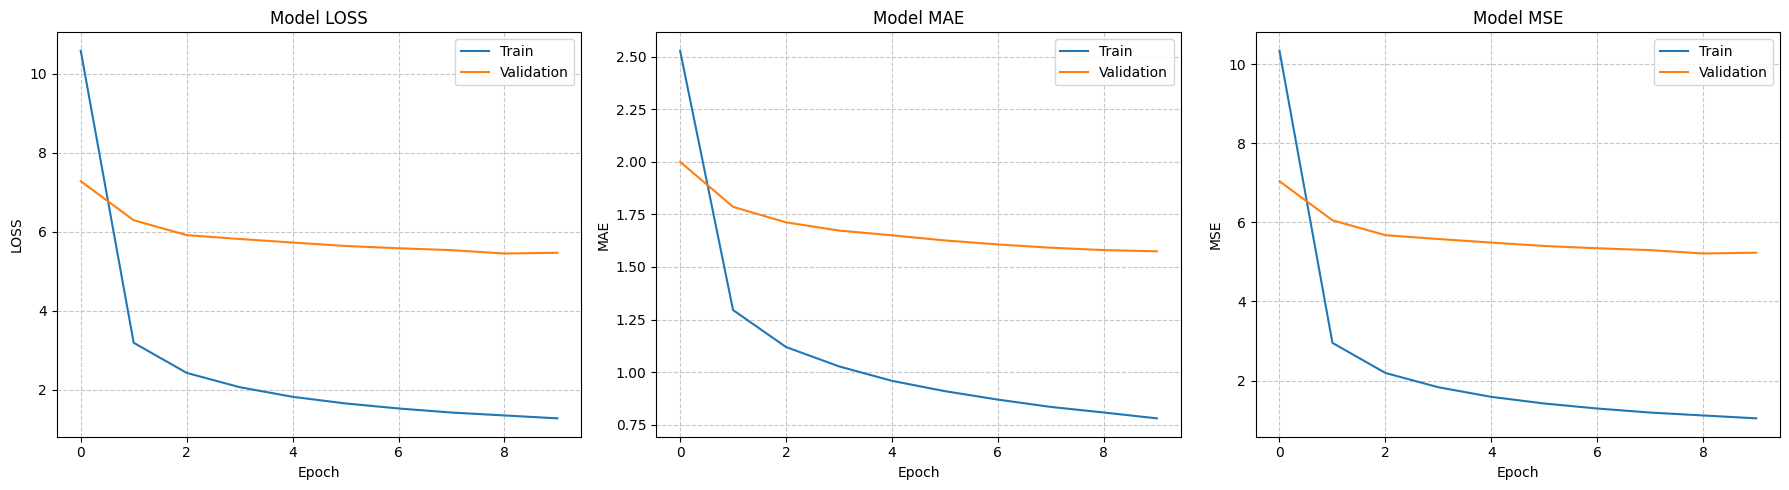


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Evaluating test set performance...{'loss': 1.9787217378616333, 'mae': 1.004310965538025, 'mse': 1.745209813117981}
R²: 0.6649926286683145
MAE: 1.0043109655380249
MSE: 1.7452098131179810
Loss: 1.9787217378616333

Generating Predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 37 ---
 Gameweek               Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       31          Cole Palmer       16.0         12.42       0.18      0.88
       31       Alexander Isak        9.7          9.16       0.24     -0.12
       31        Mohamed Salah        4.0          7.95       1.52     -2.16
       31           Phil Foden        8.8          7.87       1.11     -1.39
       31            Luis Díaz        7.0          7.50       1.52     -2.16
       31  Alexis Mac Allister        9.0          6.74       1.52     -2.16
       31 Darwin Núñez Ribeiro     

In [12]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


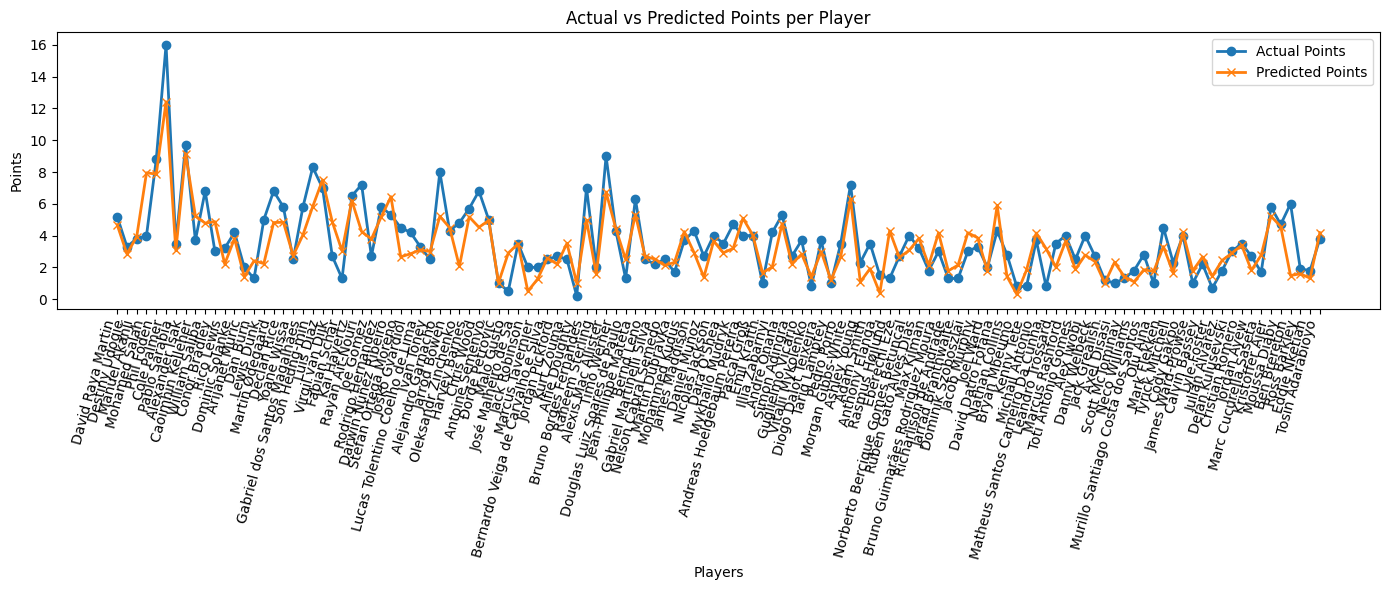

In [13]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


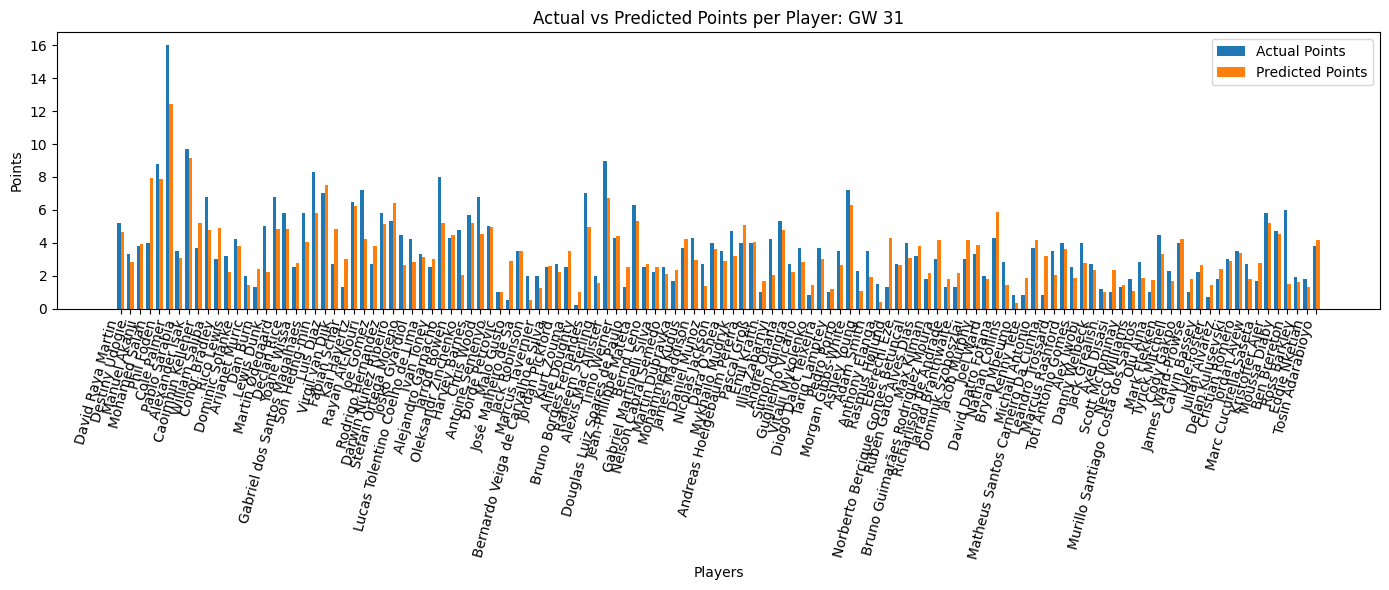

In [14]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 31")
plt.legend()

plt.tight_layout()
plt.show()


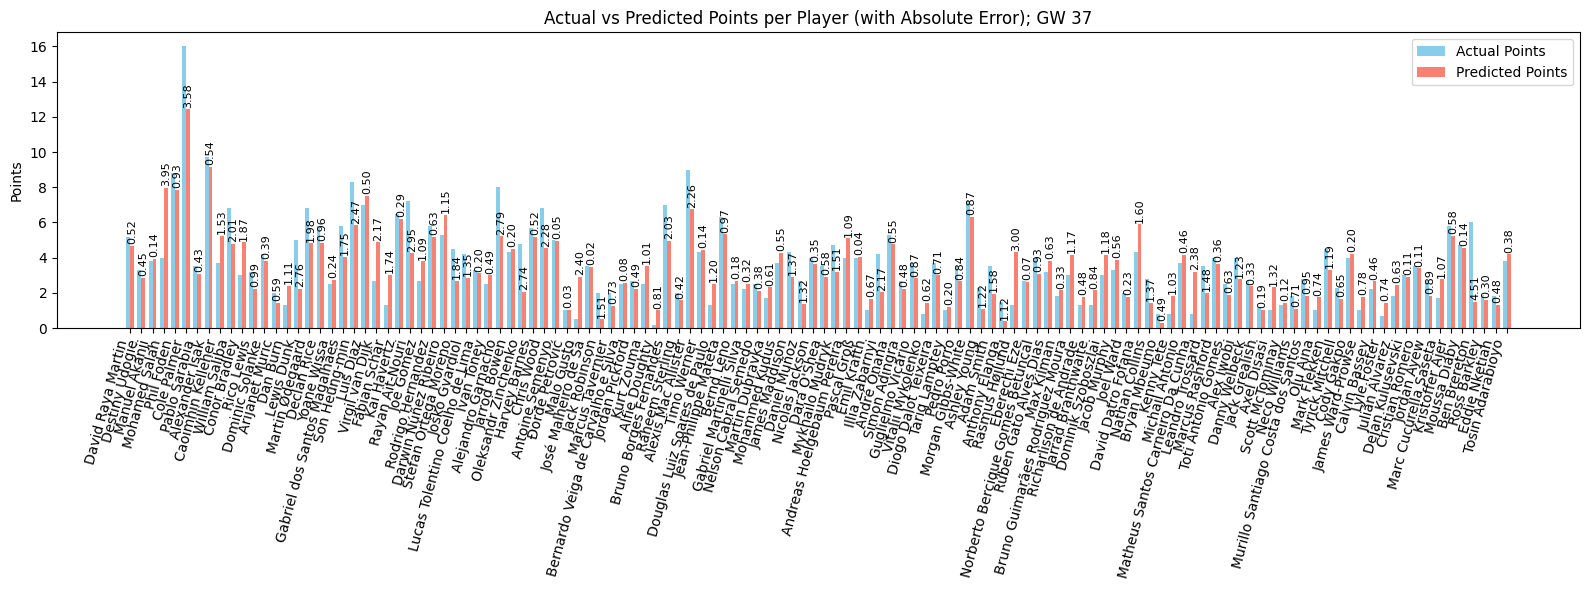

In [15]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [17]:
curr_data = final_df[final_df['round'] == 31].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-201.8013
IRL epoch 100/200 loss=-2382.1160
IRL epoch 150/200 loss=-10800.2158
IRL epoch 200/200 loss=-30787.0664
HGAT Policy Embeddings Shape: torch.Size([124, 32])
Restricted license - for non-production use only - expires 2027-11-29

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                   name               team position  price    xP_pred  \
3         Mohamed Salah          Liverpool      MID   13.3   7.951527   
4            Phil Foden    Manchester City      MID    8.1   7.868386   
21            Luis Díaz          Liverpool      MID    7.5   7.497859   
5           Cole Palmer    Manchester City      MID    5.9  12.421505   
75   Morgan Gibbs-White  Nottingham Forest      MID    5.7   6.326717   
68          André Onana  Manchester United       GK    4.9   4.749556   
7        Alexander Isak   Newcastle United      FWD    7.7   9.156672   
90   David Datro Fofana           Mainz 05      FWD    5.0   5.89

,fpl_name,team,position,xP_pred,score
3847,Mohamed Salah,Liverpool,MID,7.951527,1.0
3848,Phil Foden,Manchester City,MID,7.868386,20.0
3849,Cole Palmer,Manchester City,MID,12.421505,40.0
3851,Alexander Isak,Newcastle United,FWD,9.156672,12.0
3853,William Saliba,Arsenal,DEF,4.785260,7.0
3865,Luis Díaz,Liverpool,MID,7.497859,6.0
3866,Virgil van Dijk,Liverpool,DEF,4.865016,2.0
3912,André Onana,Manchester United,GK,4.749556,2.0
3919,Morgan Gibbs-White,Nottingham Forest,MID,6.326717,13.0
3934,David Datro Fofana,Mainz 05,FWD,5.896087,2.0


##### Rank


In [18]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

111.0 243
Your predicted player’s total of 111.0 points would rank:
→ Position: 118 out of 243 managers
→ Percentile: Top 51.44%

Closest scores around you:
    points prize
0    114.0   NaN
1    113.5   NaN
2    113.0   NaN
3    113.0   NaN
4    113.0   NaN
5    112.5   NaN
6    112.5   NaN
7    112.5   NaN
8    112.5   NaN
9    112.0   NaN
10   112.0   NaN
11   112.0   NaN
12   111.5   NaN
13   111.5   NaN
14   111.0   NaN
15   111.0   NaN
16   111.0   NaN


### GW 37


#### Predict


In [57]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 37)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 312), M shape: (4926, 3), Y shape: (4926, 2)
(4926, 312)


In [58]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 17.9979 - mae: 3.5025 - mse: 17.7300 - val_loss: 5.0132 - val_mae: 1.5955 - val_mse: 4.7440
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.9900 - mae: 1.4429 - mse: 3.7206 - val_loss: 3.5919 - val_mae: 1.2783 - val_mse: 3.3227
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0740 - mae: 1.2054 - mse: 2.8048 - val_loss: 3.1618 - val_mae: 1.1769 - val_mse: 2.8928
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4398 - mae: 1.0733 - mse: 2.1708 - val_loss: 2.9636 - val_mae: 1.1300 - val_mse: 2.6948
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2226 - mae: 1.0163 - mse: 1.9538 - val_loss: 2.8801 - val_mae: 1.1153 - val_mse: 2.6116
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0041 - mae: 0.9722 - mse: 1.7356 - val_loss: 2.7893 - val_mae: 1.0980 - val_mse: 2.5209
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8158 - mae: 0.

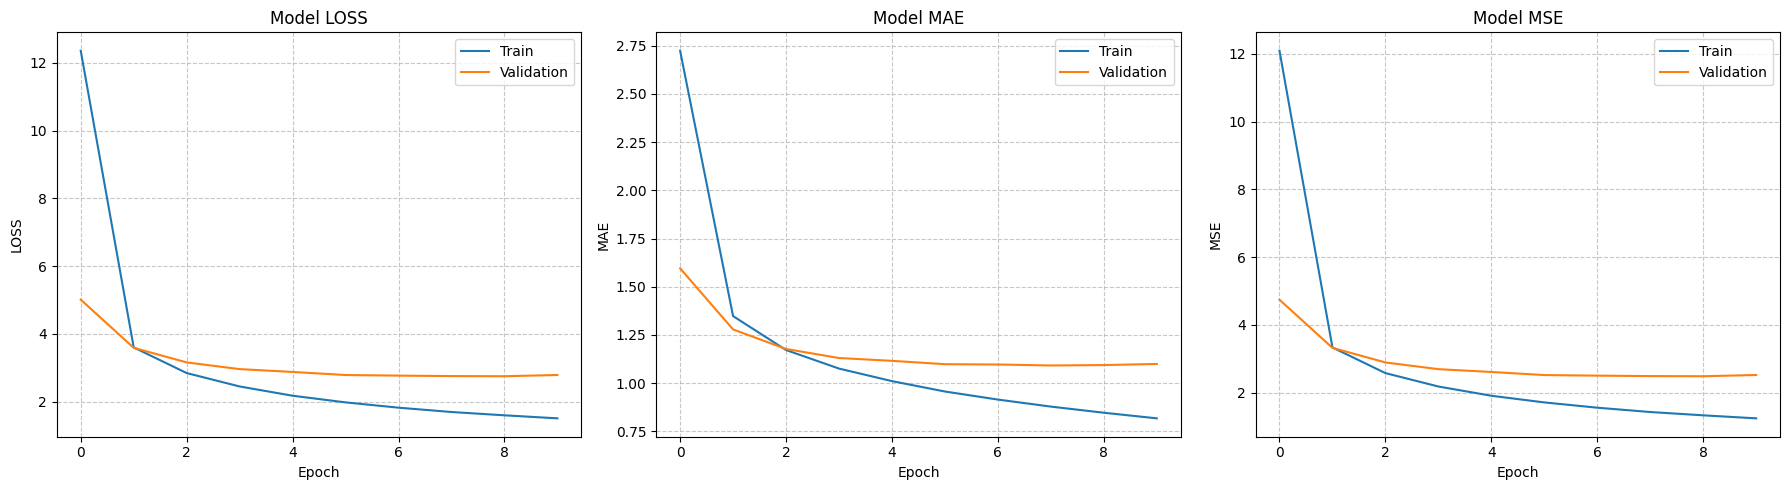


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Evaluating test set performance...{'loss': 7.925344467163086, 'mae': 1.8900055885314941, 'mse': 7.657571315765381}
R²: 0.4610877505652707
MAE: 1.8900055885314941
MSE: 7.6575713157653809
Loss: 7.9253444671630859

Generating Predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 37 ---
 Gameweek                 Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       37         Erling Haaland       17.9         13.19       0.95     -1.22
       37            Cole Palmer       10.0         12.49      -0.92     -0.14
       37         Joško Gvardiol       23.1         10.31       1.36     -1.70
       37 Bruno Borges Fernandes        7.4         10.12      -0.55      0.54
       37             Phil Foden       14.3          9.54       1.36     -1.70
       37        Nicolas Jackson       11.0          9.32       0.22     -0.10
       37         Ant

In [59]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


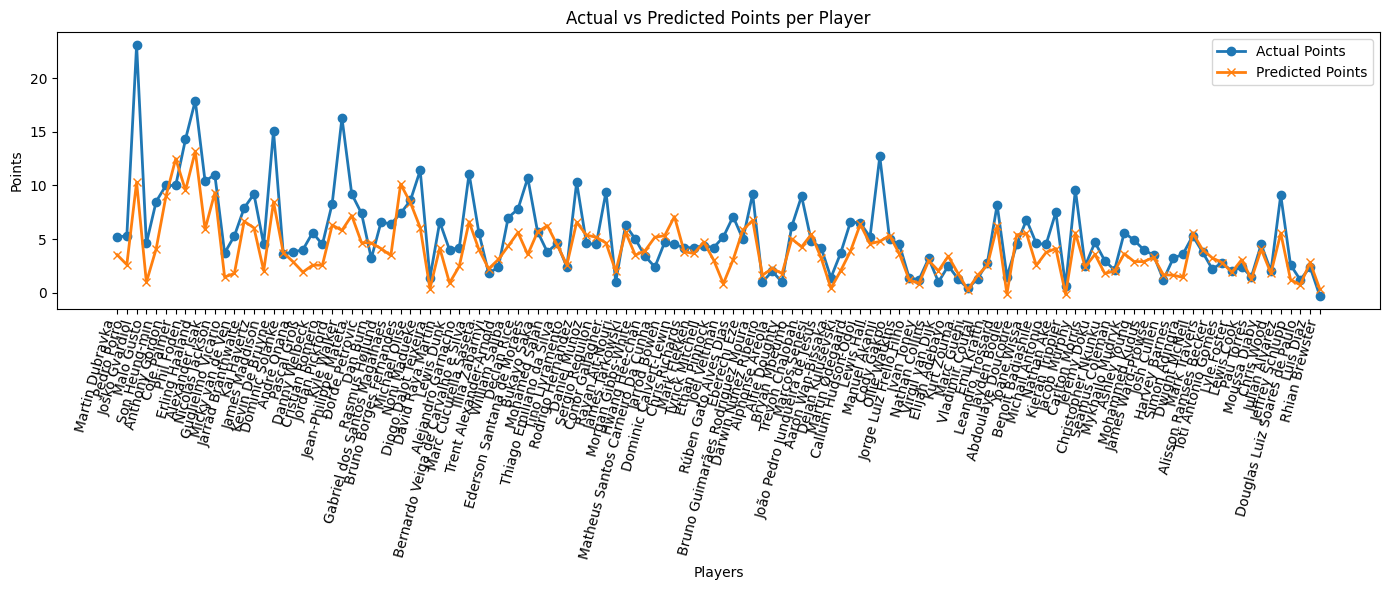

In [60]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


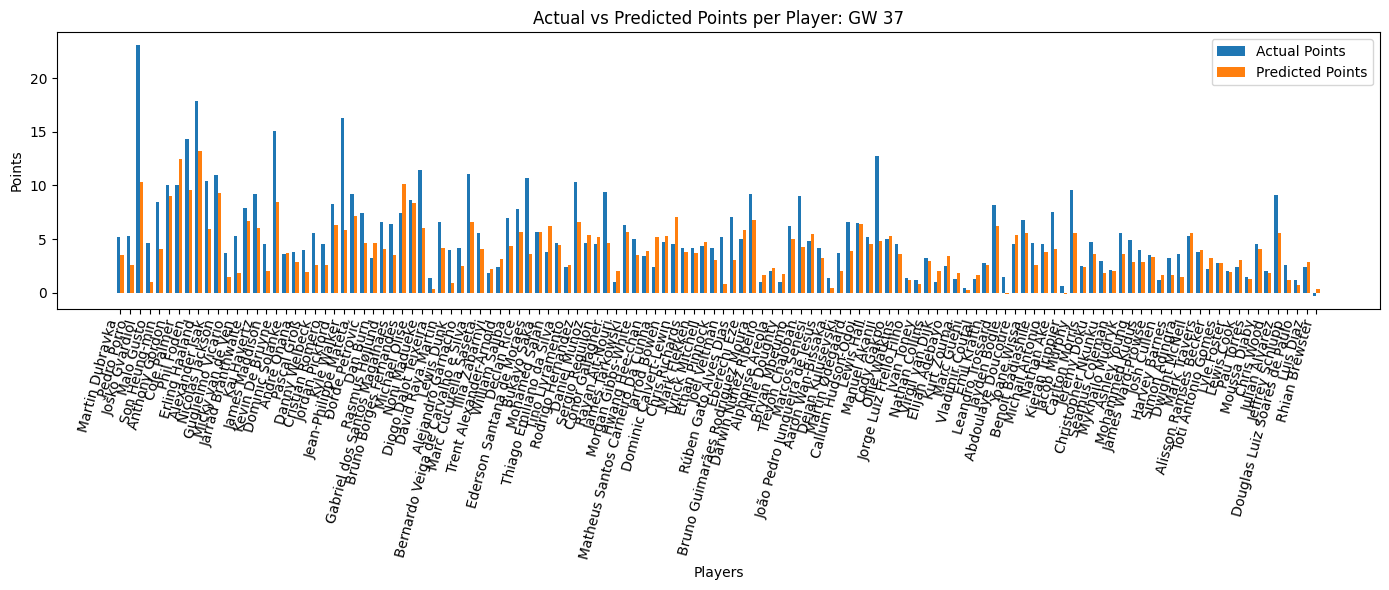

In [61]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


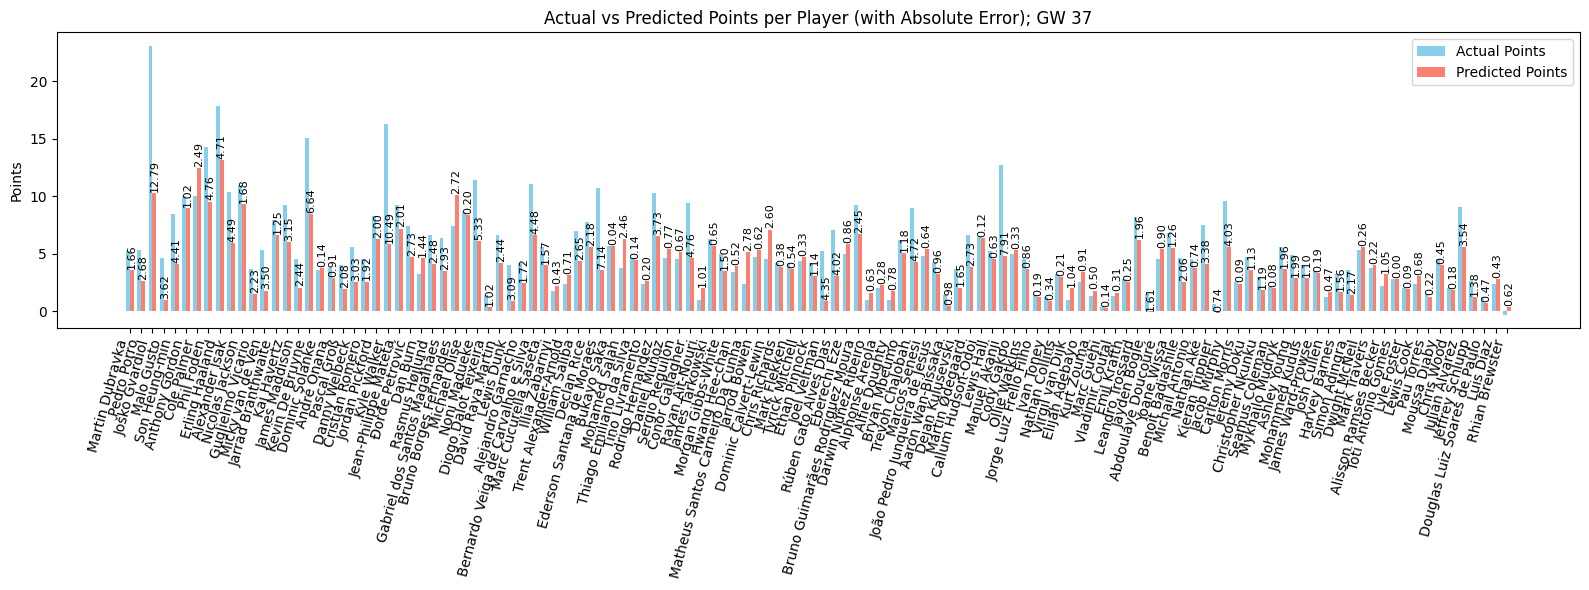

In [62]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [63]:
curr_data = final_df[final_df['round'] == 37].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-270.4471
IRL epoch 100/200 loss=-2807.0066
IRL epoch 150/200 loss=-12145.2451
IRL epoch 200/200 loss=-33750.0859
HGAT Policy Embeddings Shape: torch.Size([124, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                      name               team position  price    xP_pred  \
29  Bruno Borges Fernandes  Manchester United      MID    8.5  10.121483   
5           Anthony Gordon   Newcastle United      MID    6.4   8.984082   
6              Cole Palmer    Manchester City      MID    6.3  12.488566   
30           Michael Olise     Crystal Palace      MID    5.6   8.396700   
22         Jordan Pickford            Everton       GK    4.8   6.303754   
8           Erling Haaland    Manchester City      FWD   14.2  13.188826   
10         Nicolas Jackson            Chelsea      FWD    7.0   9.322363   
24    Jean-Philippe Mateta     Crystal Palace      FWD    5.1   7.189832   
2           Joško Gvardiol    Manch

,fpl_name,team,position,xP_pred,score
4665,Joško Gvardiol,Manchester City,DEF,10.307150,27.0
4668,Anthony Gordon,Newcastle United,MID,8.984082,8.0
4669,Cole Palmer,Manchester City,MID,12.488566,21.0
4671,Erling Haaland,Manchester City,FWD,13.188826,30.0
4673,Nicolas Jackson,Chelsea,FWD,9.322363,7.0
4676,Jarrad Branthwaite,Everton,DEF,6.653831,6.0
4685,Jordan Pickford,Everton,GK,6.303754,8.0
4687,Jean-Philippe Mateta,Crystal Palace,FWD,7.189832,9.0
4692,Bruno Borges Fernandes,Manchester United,MID,10.121483,5.0
4693,Michael Olise,Crystal Palace,MID,8.396700,12.0


##### Rank


In [64]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

142.0 243
Your predicted player’s total of 142.0 points would rank:
→ Position: 1 out of 243 managers
→ Percentile: Top 99.59%

Closest scores around you:
   points       prize
0   140.0  R 3,890.25
1   138.0  R 1,695.75
2   136.5  R 1,097.25


### GW 38


#### Predict


In [65]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 38)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 312), M shape: (4926, 3), Y shape: (4926, 2)
(4926, 312)


In [66]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.2900 - mae: 2.1569 - mse: 8.0224 - val_loss: 4.5778 - val_mae: 1.4640 - val_mse: 4.3101
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1439 - mae: 1.2672 - mse: 2.8763 - val_loss: 3.9457 - val_mae: 1.3194 - val_mse: 3.6784
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4961 - mae: 1.0920 - mse: 2.2288 - val_loss: 3.5276 - val_mae: 1.2412 - val_mse: 3.2605
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2754 - mae: 1.0329 - mse: 2.0084 - val_loss: 3.5415 - val_mae: 1.2267 - val_mse: 3.2747
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9190 - mae: 0.9524 - mse: 1.6523 - val_loss: 3.3582 - val_mae: 1.1947 - val_mse: 3.0917
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8259 - mae: 0.9138 - mse: 1.5594 - val_loss: 3.3966 - val_mae: 1.1941 - val_mse: 3.1303
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7045 - mae: 0.87

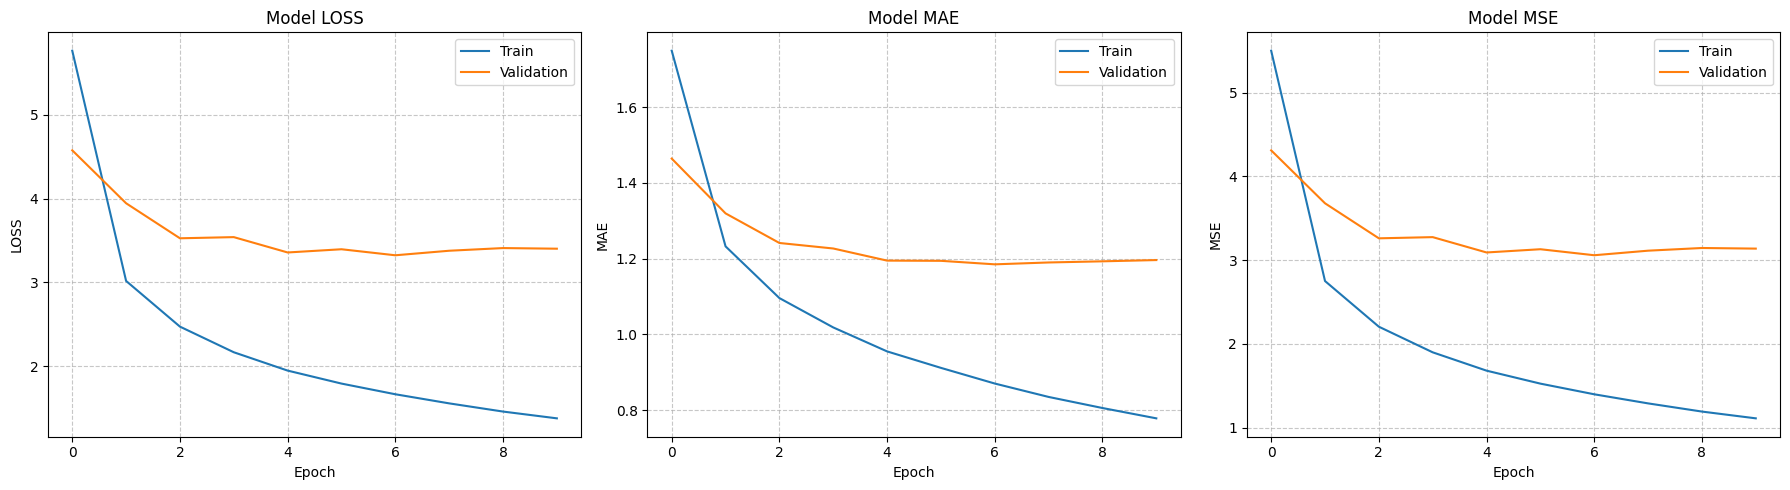


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Evaluating test set performance...{'loss': 2.315187692642212, 'mae': 1.0122894048690796, 'mse': 2.049071788787842}
R²: 0.5433240087019477
MAE: 1.0122894048690796
MSE: 2.0490717887878418
Loss: 2.3151876926422119

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

--- Results for Gameweek 37 ---
 Gameweek                             Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       38                     Joško Gvardiol       10.3         13.68       1.52     -2.13
       38                         Phil Foden        8.8         13.42       1.52     -2.13
       38                     Erling Haaland        8.2         13.37       1.52     -2.13
       38                    Kevin De Bruyne        5.2         10.49       1.52     -2.13
       38                        Cole Palmer        6.0         10.40       0.89      1.50
       38               Jean

In [67]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


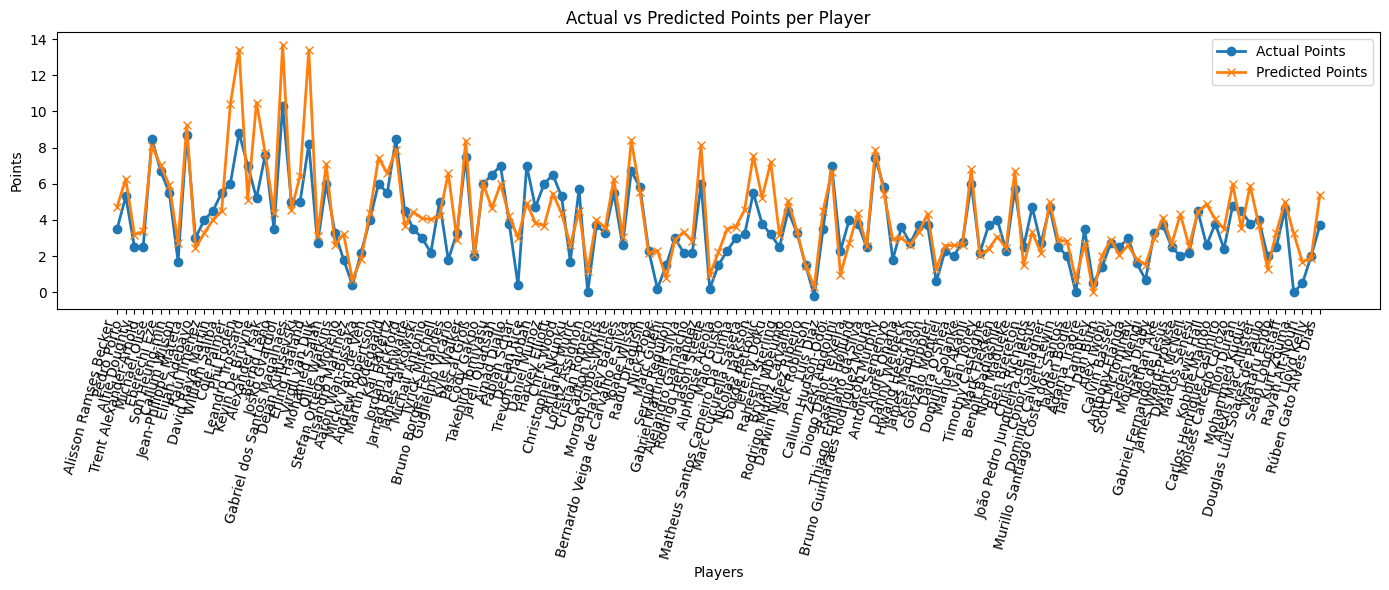

In [68]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


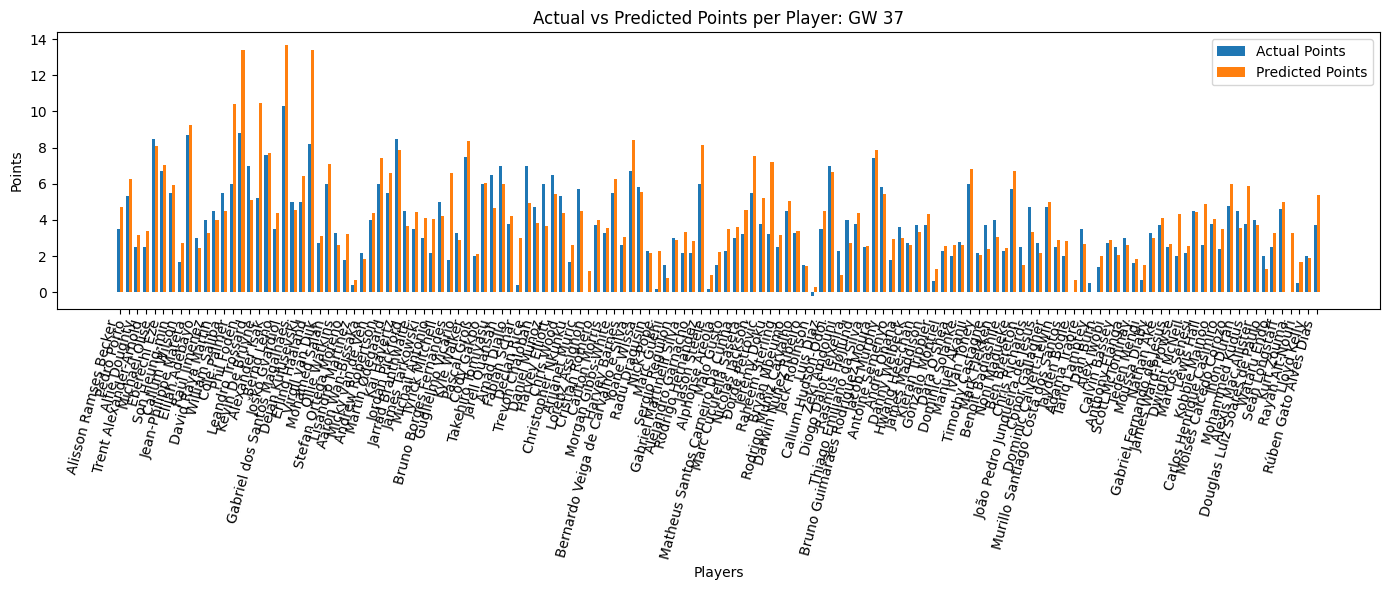

In [69]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


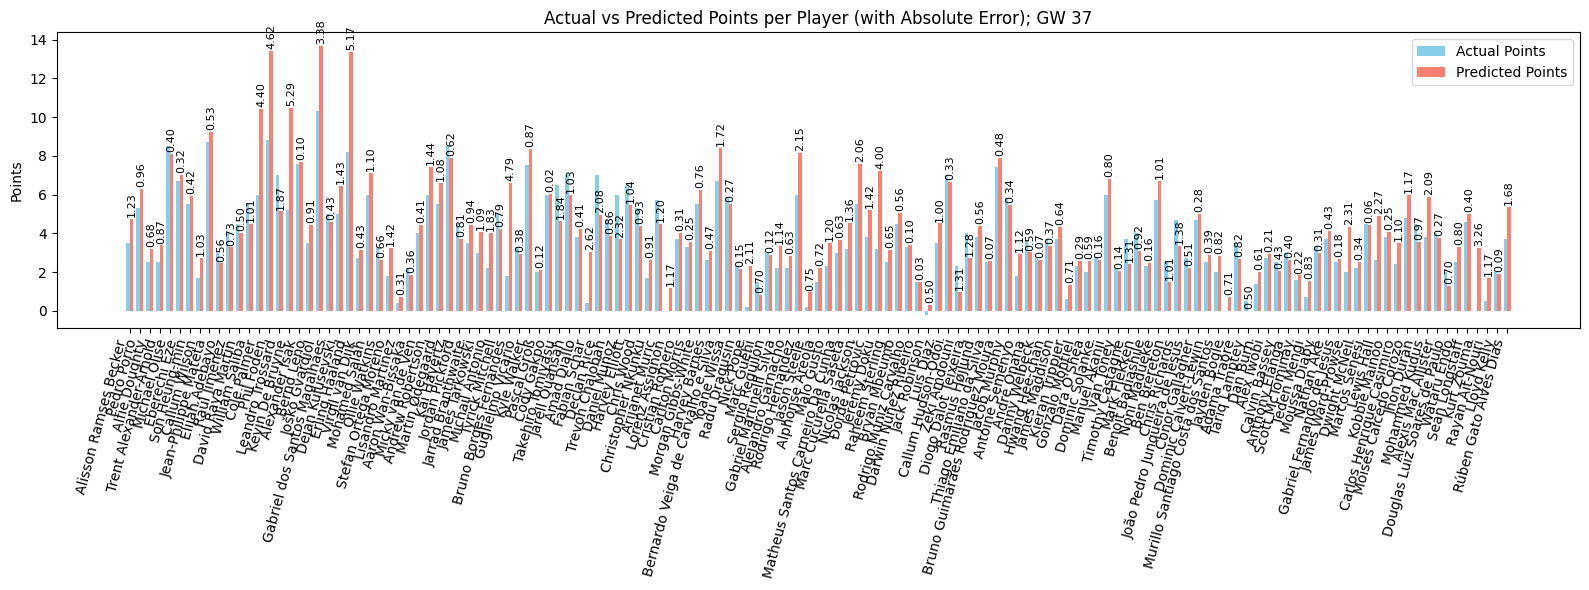

In [70]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [71]:
curr_data = final_df[final_df['round'] == 38].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-363.8551
IRL epoch 100/200 loss=-3862.4644
IRL epoch 150/200 loss=-16315.2197
IRL epoch 200/200 loss=-44542.1484
HGAT Policy Embeddings Shape: torch.Size([139, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                               name               team position  price  \
14                       Phil Foden    Manchester City      MID    8.5   
32                      Kai Havertz            Arsenal      MID    7.6   
87  Bruno Guimarães Rodriguez Moura   Newcastle United      MID    5.8   
4                     Michael Olise     Crystal Palace      MID    5.7   
74                   Đorđe Petrović            Chelsea       GK    4.7   
22                   Erling Haaland    Manchester City      FWD   14.3   
17                   Alexander Isak   Newcastle United      FWD    8.4   
8              Jean-Philippe Mateta     Crystal Palace      FWD    5.1   
30                 Andrew Robertson          Liverpoo

,fpl_name,team,position,xP_pred,score
4788,Pedro Porro,Tottenham Hotspur,DEF,6.262881,14.0
4791,Michael Olise,Crystal Palace,MID,8.095576,6.0
4795,Jean-Philippe Mateta,Crystal Palace,FWD,9.232174,20.0
4801,Phil Foden,Manchester City,MID,13.418121,22.5
4804,Alexander Isak,Newcastle United,FWD,7.700776,14.0
4806,Joško Gvardiol,Manchester City,DEF,13.678181,4.0
4809,Erling Haaland,Manchester City,FWD,13.374234,2.0
4817,Andrew Robertson,Liverpool,DEF,7.440410,8.0
4819,Kai Havertz,Arsenal,MID,7.881906,6.0
4861,Đorđe Petrović,Chelsea,GK,5.223660,3.0


##### Rank


In [72]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

115.5 243
Your predicted player’s total of 115.5 points would rank:
→ Position: 95 out of 243 managers
→ Percentile: Top 60.91%

Closest scores around you:
    points prize
0    116.5   NaN
1    116.5   NaN
2    116.5   NaN
3    116.5   NaN
4    116.5   NaN
5    116.0   NaN
6    116.0   NaN
7    116.0   NaN
8    116.0   NaN
9    116.0   NaN
10   116.0   NaN
11   116.0   NaN
12   116.0   NaN
13   116.0   NaN
14   115.5   NaN
15   115.0   NaN
16   115.0   NaN


## Predictors - 24/25


### GW 34


#### Predict


In [113]:

train_data, test_data , GW_full, X_cols = transform_data(final_df_45, cols, 39)
X_34, M_34, train_mask, Y_34, _= train_data
scaler_x, scaler_m, _, _, _ = test_data

print(X_34.shape, M_34.shape, Y_34.shape)

Data prepared. X shape: (647, 312), M shape: (647, 3), Y shape: (647, 2)
(647, 312)
(647, 312) (647, 3) (647,)


In [ ]:
data_45 = final_df_45[final_df_45['round'] ==  34]#[['season']]

train_data, test_data , GW_full, X_cols = transform_data(data_45, cols, 39)
X, M, train_mask, Y_45, Y_45_names = train_data

X_45 = scaler_x.transform(X)
M_45 = scaler_m.transform(M)

# print(X_45.shape, M_45.shape, Y_45.shape), Y_45_names

Data prepared. X shape: (115, 312), M shape: (115, 3), Y shape: (115, 2)



Starting Training...
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 19.8572 - mae: 3.8986 - mse: 19.5928 - val_loss: 1.4711 - val_mae: 0.8103 - val_mse: 1.2072
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.9831 - mae: 3.2067 - mse: 13.7193 - val_loss: 1.5555 - val_mae: 0.8565 - val_mse: 1.2921
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10.1218 - mae: 2.6053 - mse: 9.8585 - val_loss: 2.5679 - val_mae: 1.2569 - val_mse: 2.3050
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3210 - mae: 1.9783 - mse: 6.0583 - val_loss: 4.6575 - val_mae: 1.8204 - val_mse: 4.3951
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7825 - mae: 1.4839 - mse: 3.5201 - val_loss: 7.6594 - val_mae: 2.3963 - val_mse: 7.3973
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.5823 - mae: 1.1814 - mse: 2.3203 - val_loss: 10.5078 - val_mae: 2.8233 - val_mse: 10.2463
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.1656 - mae: 1.06

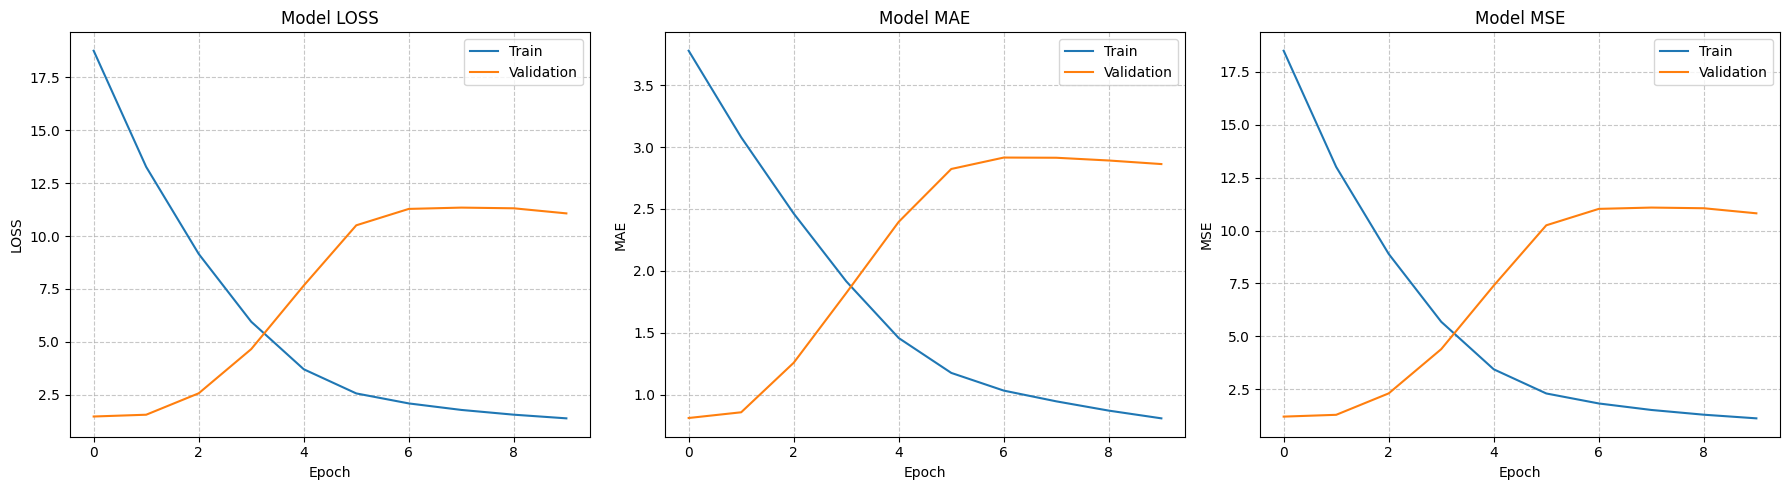

In [139]:
# Model Setup and train for the full data
INPUT_DIM_X = X_34.shape[1]
INPUT_DIM_M = M_34.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_34, M_34], Y_34,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot History
plot_training_history(history)

In [124]:
# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_45, M_45]).flatten()
Y_pred

# Results
results_df = pd.DataFrame({
    'Player': Y_45_names,
    # 'Actual_xP': Y_45,
    'Predicted_xP': Y_pred,
})

results_df


Generating Predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


,Player,Predicted_xP
0,Mohamed Salah,19.399624
1,Rayan Aït-Nouri,-5.423595
2,Matheus Santos Carneiro Da Cunha,0.143025
3,Marc Cucurella Saseta,5.314155
4,Robert Sánchez,7.645805
...,...,...
110,Victor Lindelöf,11.813386
111,Harvey Elliott,4.385127
112,Wilson Odobert,32.704021
113,Ibrahim Sangaré,9.453938


#### Optimize


In [125]:
data_45

,Unnamed: 0,fpl_id,round,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,...,opponent_team_Liverpool,opponent_team_Luton,opponent_team_Manchester City,opponent_team_Manchester United,opponent_team_Newcastle United,opponent_team_Nottingham Forest,opponent_team_Sheffield United,opponent_team_Tottenham Hotspur,opponent_team_West Ham United,opponent_team_Wolverhampton Wanderers
532,532,328.0,34,0.0,1.0,33.0,0.0,58.4,328.0,0.33,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
533,533,533.0,34,1.0,2.0,44.0,1.0,24.6,533.0,0.22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
534,534,541.0,34,2.0,3.0,76.0,1.0,61.3,541.0,0.21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
535,535,163.0,34,0.0,0.0,27.0,1.0,12.9,163.0,0.02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536,536,185.0,34,0.0,2.0,29.0,1.0,10.0,185.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,642,376.0,34,0.0,0.0,3.0,0.0,0.3,376.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
643,643,319.0,34,0.0,0.0,3.0,0.0,12.3,319.0,0.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
644,644,612.0,34,0.0,0.0,2.0,0.0,1.1,612.0,0.01,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
645,645,442.0,34,0.0,0.0,4.0,0.0,11.5,442.0,0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [138]:
# curr_data = final_df[final_df['round'] == 36].copy()
data_45['xP_pred'] = Y_pred

players = data_45[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = data_45[data_45['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

/tmp/ipython-input-2657864477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_45['xP_pred'] = Y_pred


Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-484.5256
IRL epoch 100/200 loss=-4603.6514
IRL epoch 150/200 loss=-18738.3750
IRL epoch 200/200 loss=-50334.0508
HGAT Policy Embeddings Shape: torch.Size([115, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                       name               team position  price     xP_pred  \
10              Cole Palmer            Chelsea      MID   10.6  139.408676   
81           Mathias Jensen          Brentford      MID    5.3   19.830526   
112          Wilson Odobert  Tottenham Hotspur      MID    5.3   32.704021   
56          Jordan Pickford            Everton       GK    5.1   24.934078   
103  Richarlison de Andrade  Tottenham Hotspur      FWD    6.8   44.891399   
105           William Osula   Newcastle United      FWD    4.9   21.431519   
73         Andrew Robertson          Liverpool      DEF    5.8   29.852449   
6                  Dan Burn   Newcastle United      DEF    4.5   31.457724   
89             Ja

,fpl_name,team,position,xP_pred,score
538,Dan Burn,Newcastle United,DEF,31.457724,13.0
542,Cole Palmer,Chelsea,MID,139.408676,6.0
588,Jordan Pickford,Everton,GK,24.934078,4.0
595,Joachim Andersen,Crystal Palace,DEF,31.745993,2.0
605,Andrew Robertson,Liverpool,DEF,29.852449,2.0
613,Mathias Jensen,Brentford,MID,19.830526,1.0
617,Vitalii Mykolenko,Everton,DEF,26.058420,2.0
621,Jake O'Brien,Everton,DEF,29.779156,2.0
635,Richarlison de Andrade,Tottenham Hotspur,FWD,44.891399,0.0
637,William Osula,Newcastle United,FWD,21.431519,6.0


##### Rank


In [ ]:
fg_managers_24_25 = fg_managers_24_25.rename(columns={'Points':'points', 'Gameweek': 'gameweek'})

,userContestId,Gameweek,Event,Season,CompletedAt,ContestEntries,EntryFees,Rank,Username,points,Formation,Players
0,90371,Gameweek 38,English Premier League,2024/25,2025-05-26T06:46:58.502Z,1785,10,1,big mouth,94.5,1-3-4-3,"[{'name': 'Gakpo', 'firstName': 'Cody', 'lastN..."
1,94301,Gameweek 38,English Premier League,2024/25,2025-05-26T06:46:58.502Z,1785,10,4,EDWIN K,90.0,1-3-5-2,"[{'name': 'M.Salah', 'firstName': 'Mohamed', '..."
2,94896,Gameweek 38,English Premier League,2024/25,2025-05-26T06:46:58.502Z,1785,10,2,undefeateddevil,92.0,1-5-3-2,"[{'name': 'M.Salah', 'firstName': 'Mohamed', '..."
3,92438,Gameweek 38,English Premier League,2024/25,2025-05-26T06:46:58.502Z,1785,10,4,user92057197,90.0,1-3-5-2,"[{'name': 'Gakpo', 'firstName': 'Cody', 'lastN..."
4,91023,Gameweek 38,English Premier League,2024/25,2025-05-26T06:46:58.502Z,1785,10,11,LAmost,86.0,1-3-5-2,"[{'name': 'M.Salah', 'firstName': 'Mohamed', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8211,40728,Gameweek 34,English Premier League,2024/25,2025-05-02T07:14:00.895Z,1474,10,1467,Elñino,22.5,1-4-3-3,"[{'name': 'S.Bueno', 'firstName': 'Santiago', ..."
8212,44162,Gameweek 34,English Premier League,2024/25,2025-05-02T07:14:00.895Z,1474,10,1472,qalabocha,17.0,1-3-5-2,"[{'name': 'Wissa', 'firstName': 'Yoane', 'last..."
8213,45887,Gameweek 34,English Premier League,2024/25,2025-05-02T07:14:00.895Z,1474,10,1468,Spit fire 🔥,22.0,1-5-4-1,"[{'name': 'Dawson', 'firstName': 'Craig', 'las..."
8214,45221,Gameweek 34,English Premier League,2024/25,2025-05-02T07:14:00.895Z,1474,10,1473,Sihlewest,13.0,1-4-3-3,"[{'name': 'Jones', 'firstName': 'Curtis', 'las..."


In [137]:
# Rank position (how many have >= your score)
# fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
# fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
# fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
# fg_managers = fg_managers[fg_managers['gameweek']== 37]
# fg_managers[['points']]

fg_managers_34 = fg_managers_24_25.rename(columns={'Points':'points', 'Gameweek': 'gameweek'})
fg_managers_34 = fg_managers[fg_managers['gameweek']== "Gameweek 34"]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

39.0 243
Your predicted player’s total of 39.0 points would rank:
→ Position: 242 out of 243 managers
→ Percentile: Top 0.41%

Closest scores around you:
    points prize
0     78.5   NaN
1     76.5   NaN
2     75.0   NaN
3     74.0   NaN
4     72.0   NaN
5     70.0   NaN
6     70.0   NaN
7     69.5   NaN
8     69.5   NaN
9     67.0   NaN
10    63.5   NaN
11    60.0   NaN
12    57.5   NaN
13    49.5   NaN
14    34.5   NaN
15    28.0   NaN


### GW 37


#### Predict


In [ ]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 37)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [ ]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 11.1820 - mae: 2.6371 - mse: 10.9481 - val_loss: 4.6576 - val_mae: 1.5281 - val_mse: 4.4229
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.1035 - mae: 1.4159 - mse: 3.8687 - val_loss: 3.5975 - val_mae: 1.2906 - val_mse: 3.3628
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1070 - mae: 1.2246 - mse: 2.8722 - val_loss: 3.0652 - val_mae: 1.1734 - val_mse: 2.8304
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.7585 - mae: 1.1307 - mse: 2.5237 - val_loss: 2.8907 - val_mae: 1.1310 - val_mse: 2.6560
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.4592 - mae: 1.0559 - mse: 2.2246 - val_loss: 2.8015 - val_mae: 1.1085 - val_mse: 2.5670
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0594 - mae: 0.9804 - mse: 1.8250 - val_loss: 2.7286 - val_mae: 1.0897 - val_mse: 2.4944
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8871 - mae: 0.

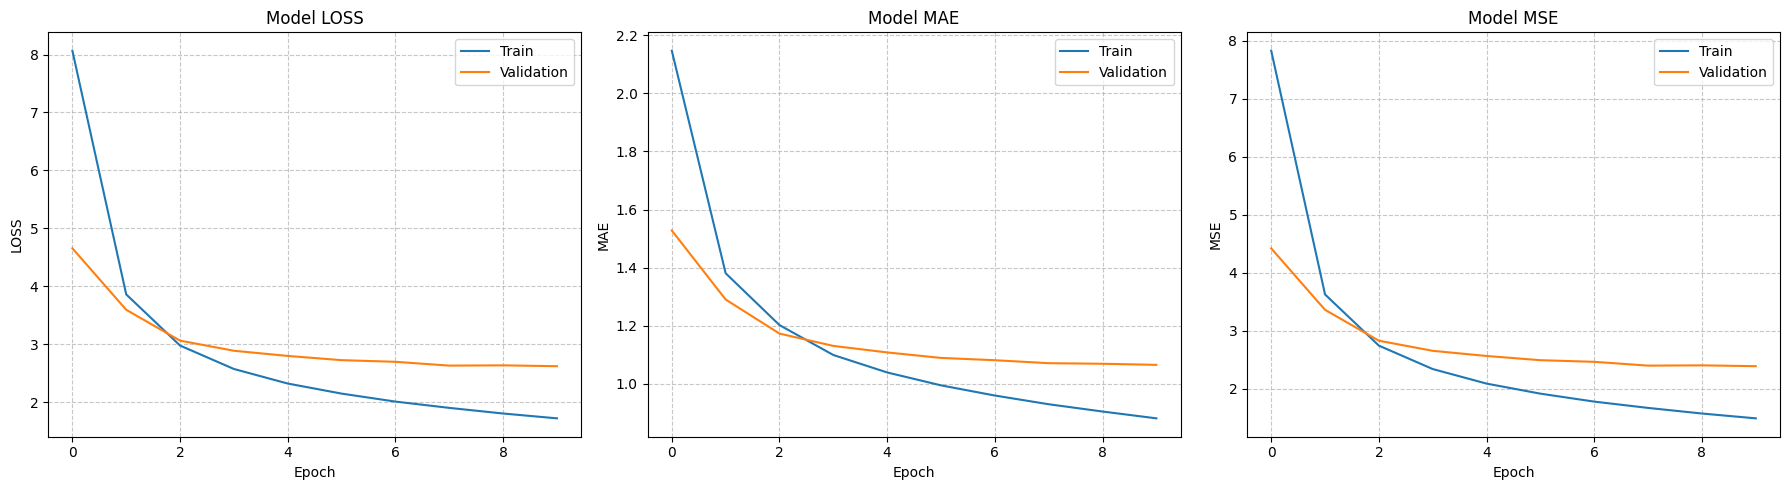


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Evaluating test set performance...{'loss': 7.177196979522705, 'mae': 1.8208918571472168, 'mse': 6.94387149810791}
R²: 0.5113154540383698
MAE: 1.8208918571472168
MSE: 6.9438714981079102
Loss: 7.1771969795227051

Generating Predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

--- Results for Gameweek 37 ---
 Gameweek                 Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       37         Erling Haaland       17.9         13.80       0.95     -1.22
       37             Phil Foden       14.3         11.49       1.36     -1.70
       37        Nicolas Jackson       11.0         10.71       0.22     -0.10
       37         Joško Gvardiol       23.1         10.30       1.36     -1.70
       37            Cole Palmer       10.0          9.80      -0.92     -0.14
       37        Kevin De Bruyne       15.1          9.67       1.36     -1.70
       37          Mic

In [ ]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


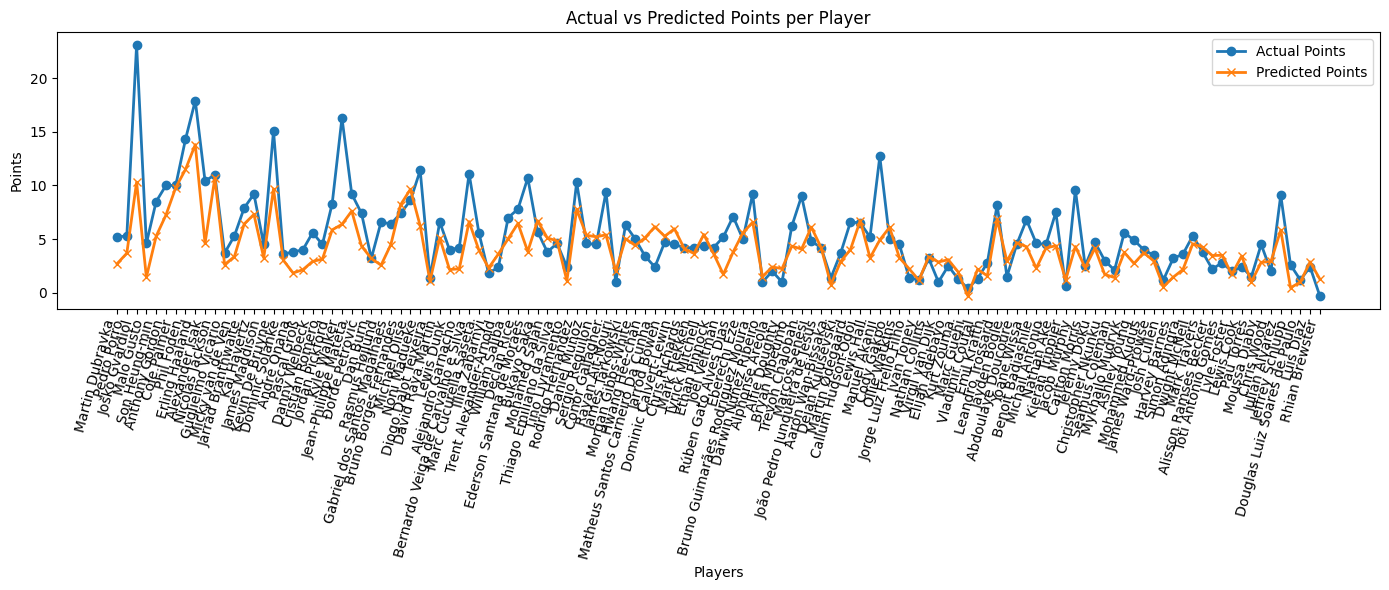

In [ ]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


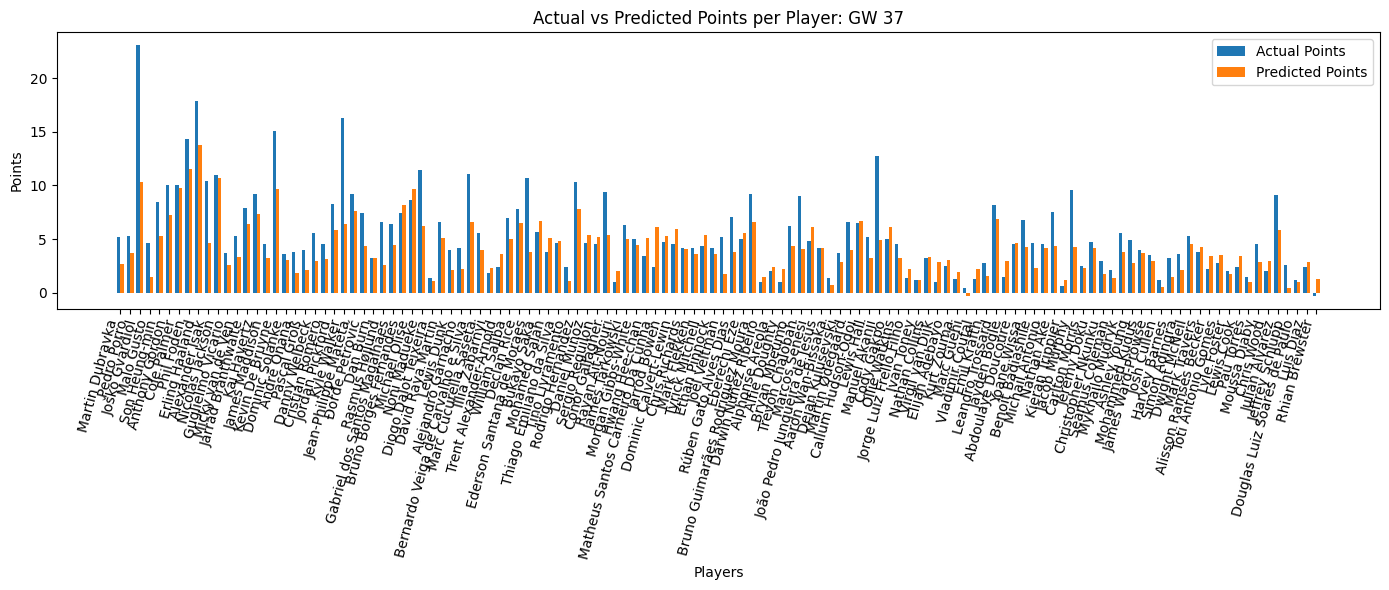

In [ ]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


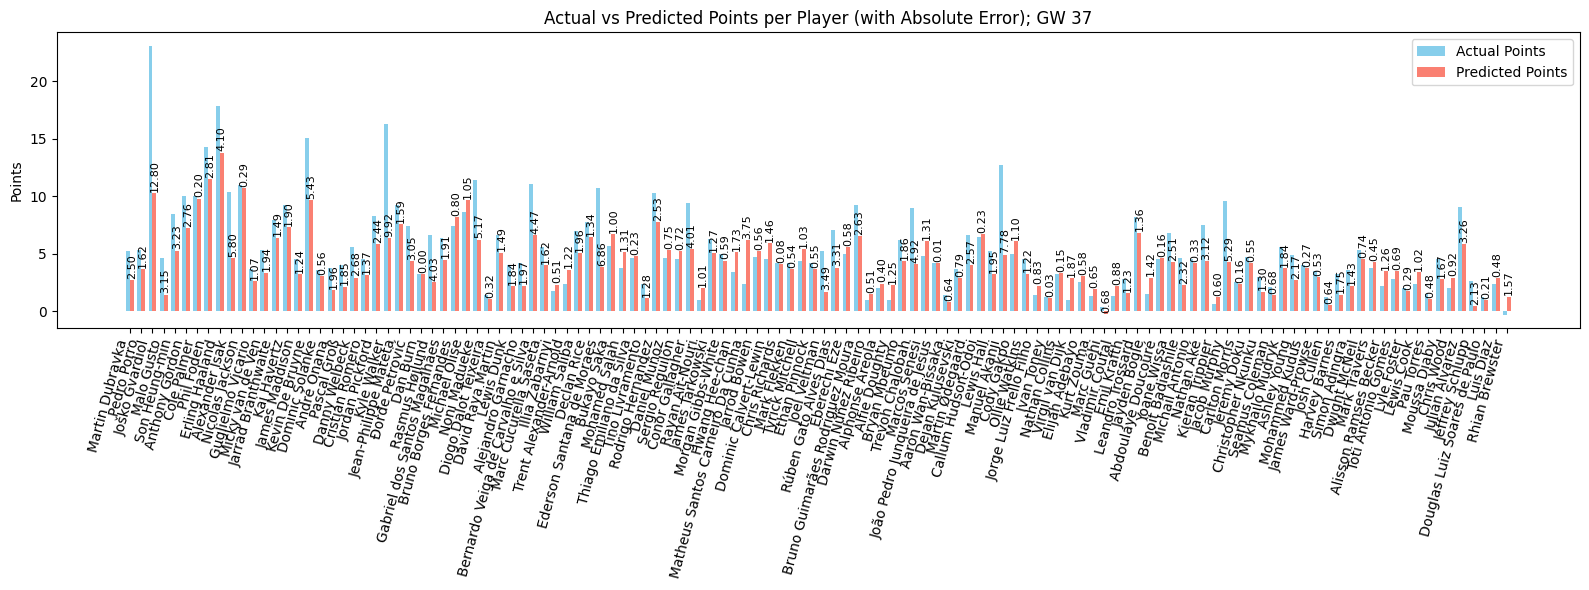

In [ ]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [ ]:
curr_data = final_df[final_df['round'] == 37].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11


IRL epoch 50/200 loss=-448.2607
IRL epoch 100/200 loss=-5063.0791
IRL epoch 150/200 loss=-21817.0762
IRL epoch 200/200 loss=-60637.3320
HGAT Policy Embeddings Shape: torch.Size([124, 32])
Restricted license - for non-production use only - expires 2027-11-29

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                      name               team position  price    xP_pred  \
7               Phil Foden    Manchester City      MID    8.5  11.489194   
29  Bruno Borges Fernandes  Manchester United      MID    8.5   8.201226   
14             Kai Havertz            Arsenal      MID    7.5   7.300558   
30           Michael Olise     Crystal Palace      MID    5.6   9.647214   
22         Jordan Pickford            Everton       GK    4.8   5.861188   
8           Erling Haaland    Manchester City      FWD   14.2  13.803748   
10         Nicolas Jackson            Chelsea      FWD    7.0  10.713554   
24    Jean-Philippe Mateta     Crystal Palace      FWD    5.1   7.612991   
2         

,fpl_name,team,position,xP_pred,score
4665,Joško Gvardiol,Manchester City,DEF,10.301388,27.0
4670,Phil Foden,Manchester City,MID,11.489194,16.5
4671,Erling Haaland,Manchester City,FWD,13.803748,30.0
4673,Nicolas Jackson,Chelsea,FWD,10.713554,7.0
4676,Jarrad Branthwaite,Everton,DEF,6.405490,6.0
4677,Kai Havertz,Arsenal,MID,7.300558,6.0
4685,Jordan Pickford,Everton,GK,5.861188,8.0
4687,Jean-Philippe Mateta,Crystal Palace,FWD,7.612991,9.0
4692,Bruno Borges Fernandes,Manchester United,MID,8.201226,5.0
4693,Michael Olise,Crystal Palace,MID,9.647214,12.0


##### Rank


In [ ]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

130.5 243
Your predicted player’s total of 130.5 points would rank:
→ Position: 10 out of 243 managers
→ Percentile: Top 95.88%

Closest scores around you:
    points       prize
0    140.0  R 3,890.25
1    138.0  R 1,695.75
2    136.5  R 1,097.25
3    133.0    R 460.75
4    133.0    R 460.75
5    132.5    R 249.38
6    132.5    R 249.38
7    131.5     R 99.75
8    131.0     R 99.75
9    130.0     R 24.94
10   130.0     R 24.94
11   130.0     R 24.94


### GW 38


#### Predict


In [ ]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 38)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [ ]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 16.1652 - mae: 3.1522 - mse: 15.9324 - val_loss: 6.7213 - val_mae: 1.7891 - val_mse: 6.4875
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.2256 - mae: 1.4876 - mse: 3.9917 - val_loss: 4.4601 - val_mae: 1.4071 - val_mse: 4.2263
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0827 - mae: 1.2311 - mse: 2.8488 - val_loss: 3.8925 - val_mae: 1.2884 - val_mse: 3.6588
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5985 - mae: 1.1178 - mse: 2.3647 - val_loss: 3.6430 - val_mae: 1.2336 - val_mse: 3.4095
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5030 - mae: 1.0933 - mse: 2.2695 - val_loss: 3.5374 - val_mae: 1.2113 - val_mse: 3.3041
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1781 - mae: 1.0205 - mse: 1.9448 - val_loss: 3.3793 - val_mae: 1.1868 - val_mse: 3.1463
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8812 - mae: 0.

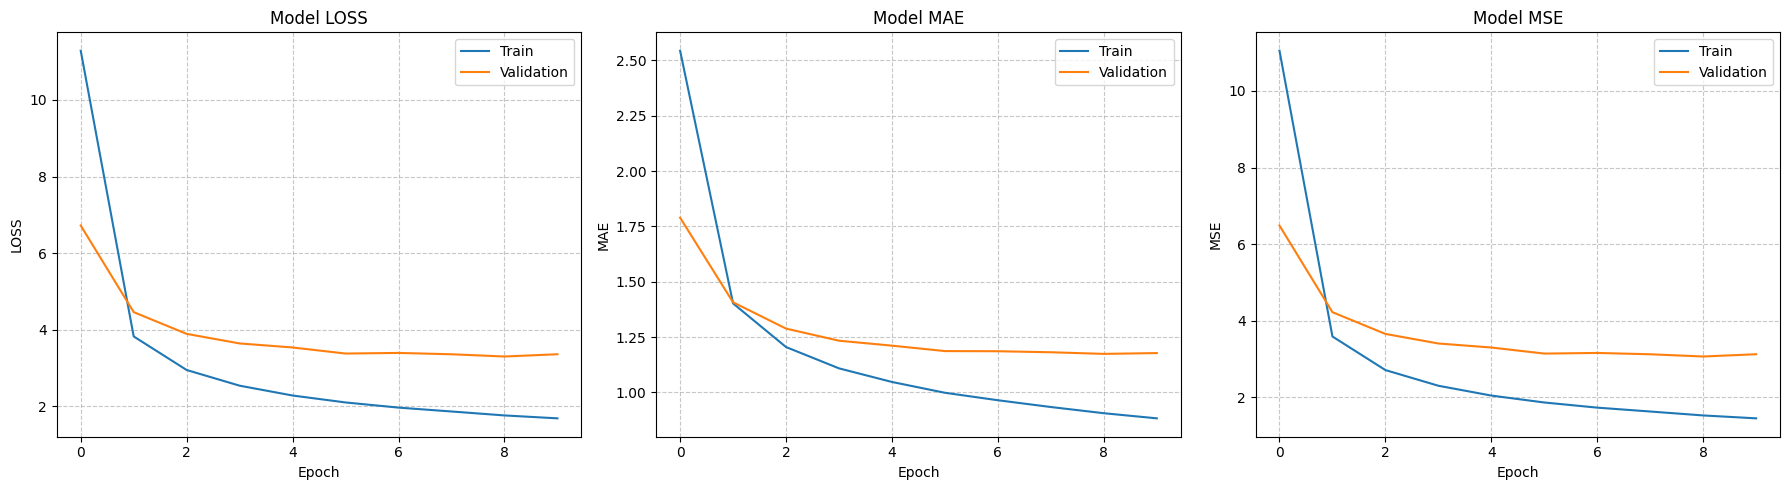


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Evaluating test set performance...{'loss': 2.425461530685425, 'mae': 1.0381990671157837, 'mse': 2.193310260772705}
R²: 0.5111776377316507
MAE: 1.0381990671157837
MSE: 2.1933102607727051
Loss: 2.4254615306854248

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 37 ---
 Gameweek                             Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       38                     Joško Gvardiol       10.3         14.36       1.52     -2.13
       38                         Phil Foden        8.8         14.06       1.52     -2.13
       38                     Erling Haaland        8.2         13.45       1.52     -2.13
       38    Bruno Guimarães Rodriguez Moura        7.4          9.72      -0.05      0.12
       38 Bernardo Veiga de Carvalho e Silva        6.7          9.48       1.52     -2.13
       38               Jean

In [ ]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


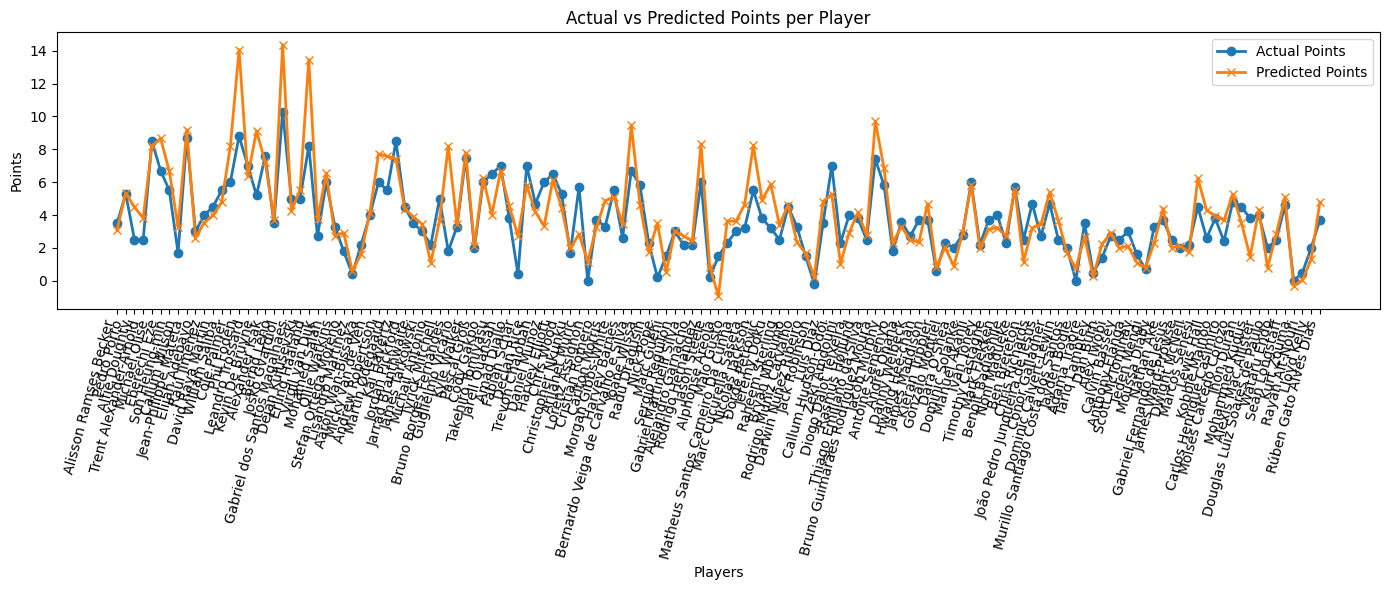

In [ ]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


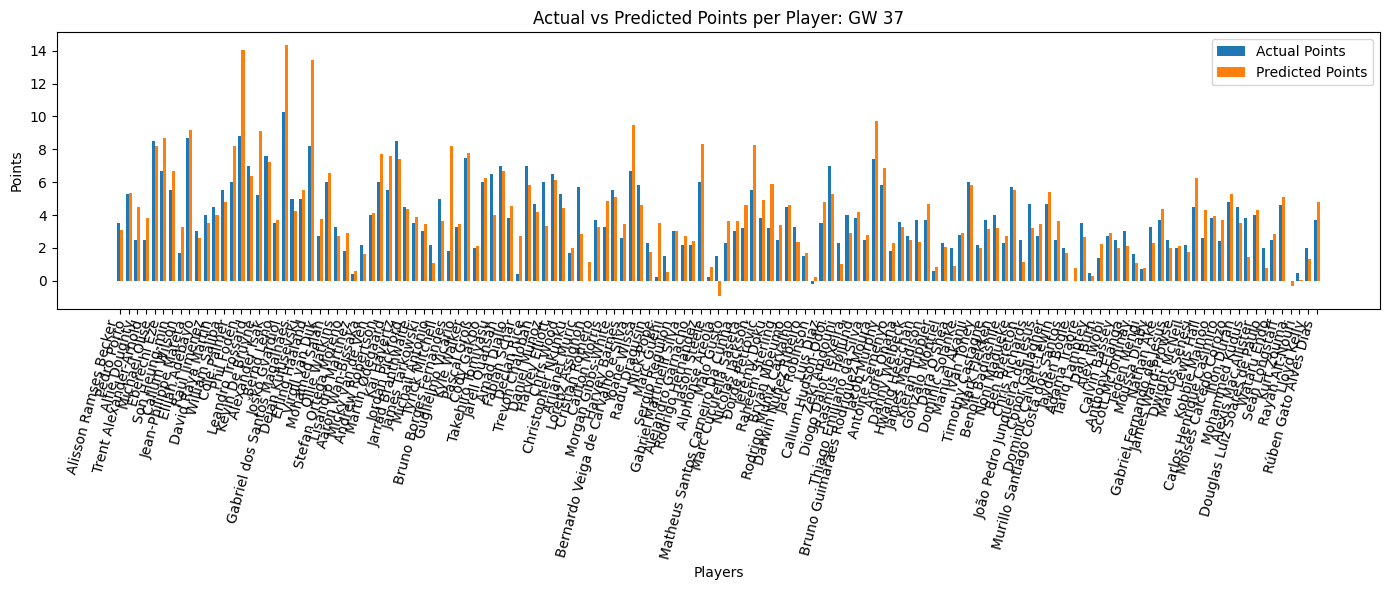

In [ ]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


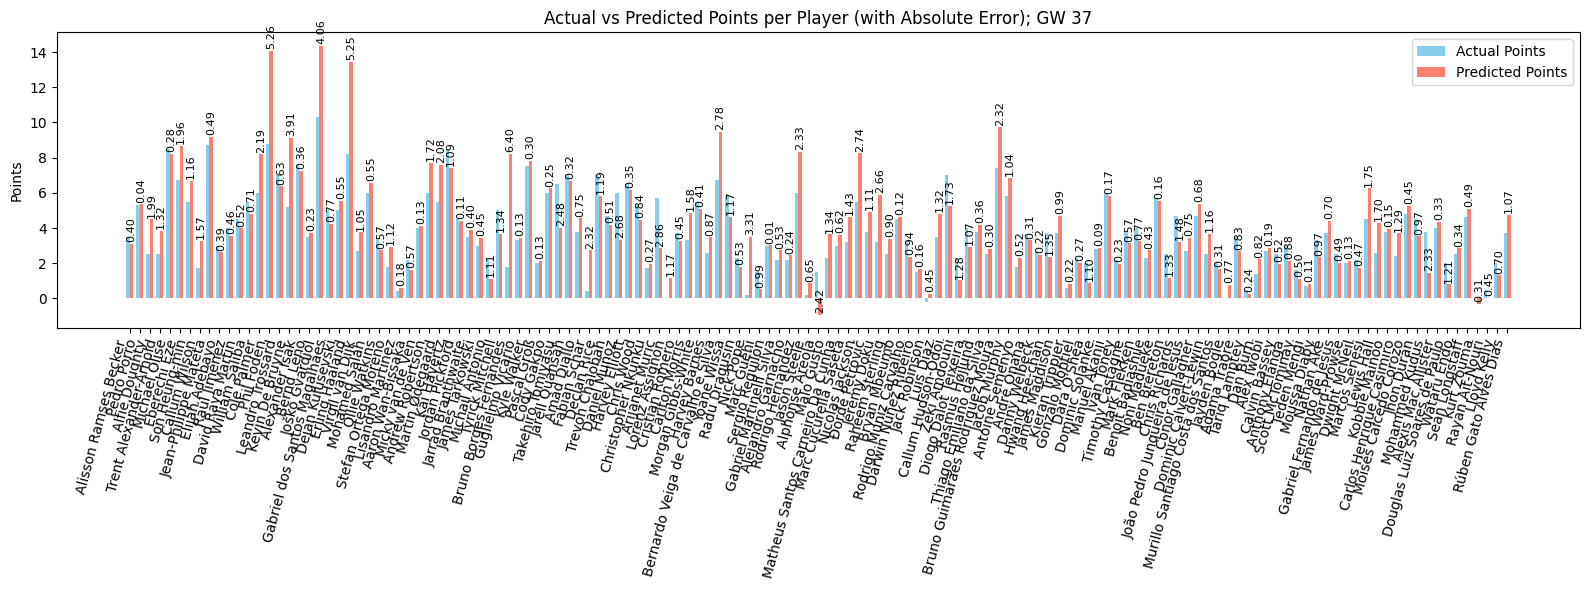

In [ ]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [ ]:
curr_data = final_df[final_df['round'] == 38].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-223.0764
IRL epoch 100/200 loss=-2376.4246
IRL epoch 150/200 loss=-10026.4590
IRL epoch 200/200 loss=-27359.1465
HGAT Policy Embeddings Shape: torch.Size([139, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                               name               team position  price  \
14                       Phil Foden    Manchester City      MID    8.5   
38           Bruno Borges Fernandes  Manchester United      MID    8.5   
5                      Eberechi Eze     Crystal Palace      MID    6.0   
87  Bruno Guimarães Rodriguez Moura   Newcastle United      MID    5.8   
74                   Đorđe Petrović            Chelsea       GK    4.7   
22                   Erling Haaland    Manchester City      FWD   14.3   
73                  Nicolas Jackson            Chelsea      FWD    7.0   
8              Jean-Philippe Mateta     Crystal Palace      FWD    5.1   
30                 Andrew Robertson          Liverpoo

,fpl_name,team,position,xP_pred,score
4792,Eberechi Eze,Crystal Palace,MID,8.662853,18.0
4795,Jean-Philippe Mateta,Crystal Palace,FWD,9.192301,20.0
4801,Phil Foden,Manchester City,MID,14.064911,22.5
4806,Joško Gvardiol,Manchester City,DEF,14.357425,4.0
4809,Erling Haaland,Manchester City,FWD,13.453543,2.0
4817,Andrew Robertson,Liverpool,DEF,7.718508,8.0
4825,Bruno Borges Fernandes,Manchester United,MID,8.200953,0.0
4831,Jarell Quansah,Liverpool,DEF,6.676021,15.0
4860,Nicolas Jackson,Chelsea,FWD,8.235381,2.0
4861,Đorđe Petrović,Chelsea,GK,4.914685,3.0


##### Rank


In [ ]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

110.5 243
Your predicted player’s total of 110.5 points would rank:
→ Position: 124 out of 243 managers
→ Percentile: Top 48.97%

Closest scores around you:
    points prize
0    112.5   NaN
1    112.5   NaN
2    112.5   NaN
3    112.0   NaN
4    112.0   NaN
5    112.0   NaN
6    111.5   NaN
7    111.5   NaN
8    111.0   NaN
9    111.0   NaN
10   111.0   NaN
11   111.0   NaN
12   111.0   NaN
13   111.0   NaN
14   110.5   NaN
15   110.5   NaN
16   109.5   NaN
